# 07 - Results: learned volt-var curves against fixed curves and the feeder-wide optimum

Notebooks 01 to 06 built the study step by step: the CIGRE European MV feeder in OpenDSS
(CIGRE TB 575, feeder 1, TR1 at +4.375 %), nine PV units of 680 to 740 kW at buses 3 to 11
with inverters of 1.1 Pmpp, a synthetic year 2023 at 15-minute steps, fixed IEEE 1547-2018
volt-var curves and a per-step OPF as references, a learning environment with a shared
reward and a physics safety layer (the fence), and local agents trained with soft
actor-critic to set the upper half of their own curve (V3, V4, Q4) every 15 minutes.

This notebook gathers the results in one place and asks three further questions that the
earlier notebooks left open:

1. **Is the lazy curve just one lucky hand pick?** A grid of 15 fixed curves shows where the
   best fixed curve lies and whether the learned policies beat it.
2. **How much of the learned policies' clean record is the fence?** The three kept policies
   are run once more on the full year with the fence switched off.
3. **Do the results hold on a year the policies have never seen?** The kept checkpoints
   were selected on the 2023 evaluation year itself. A second year of profiles, generated by
   the same models with a different seed, removes that selection advantage.

Everything else is read from the files written by notebooks 03 to 06. Most figures are
stacked panels sharing one legend below the axes; each is also saved to `figures/`.

Steps:

1. Setup: load every saved run and check it against the stored numbers.
2. The controllers: fixed curves and the curves the agents learned.
3. The full year: violations, losses, reactive energy and reward.
4. A grid of fixed curves: where is the best fixed curve?
5. Voltage: duration curves of the feeder maximum.
6. When the reactive energy is spent: day-by-hour maps and months.
7. Where the reactive energy is spent: unit by unit, against the OPF.
8. Two days hour by hour: the worst day and a typical sunny day.
9. The sampled days: distance to the OPF bound.
10. The role of the fence.
11. A second, unseen year.
12. Two details of the learned policies: the irradiance input and steep curves.
13. Limitations.
14. Conclusions.
15. Save `results_summary.json`.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import json, time, os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch
import opendssdirect as dss

import cigre_dss as cd
import simulate as sim
import profiles as pf
import kpi
import env
import agents
from env import EnvConfig, VoltVarEnv

T_NB0 = time.perf_counter()
torch.set_num_threads(2)
YEAR, DT_H, SPD = 2023, sim.DT_H, 96
PV_BUSES, PV_KW, PV_KVA, F1 = list(sim.PV_BUSES), sim.PV_KW, sim.PV_KVA, list(sim.F1_BUSES)
SEEDS = (0, 1, 2)

pv, loads, attrs = sim.load_year("profiles_2023.h5")
sel = json.load(open("selected_days_2023.json"))
base = json.load(open("baselines_2023.json"))
envcfg = json.load(open("env_config.json"))
summ = json.load(open("train_summary.json"))
CFG = EnvConfig.from_dict(envcfg["env"])
CFG_OFF = EnvConfig.from_dict({**envcfg["env"], "safety_layer": False})
D_WORST, D_TYP = sel["worst_day_index"], sel["typical_day_index"]
SAMPLE_DAYS = base["sample_days"]
with h5py.File("train_2023.h5", "r") as f:
    DIST_KM = np.asarray(f.attrs["distance_km"], dtype=float)
JJ = np.argsort(DIST_KM)                                   # units ordered by distance from bus 1
h = np.arange(0, 24, DT_H)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
os.makedirs("../figures", exist_ok=True)

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9})
def legend_below(ax, ncol=3, dy=-0.15, **kw):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, dy), ncol=ncol, frameon=False, **kw)
def save(fig, name):
    fig.savefig(os.path.join("../figures", f"07_{name}.png"), dpi=150, bbox_inches="tight")

NAME = {"unity": "unity pf", "default": "default curve", "tight": "tight curve", "lazy": "lazy curve",
        "sac0": "learned, seed 0", "sac1": "learned, seed 1", "sac2": "learned, seed 2",
        "opf": "OPF bound", "opf_loss": "OPF, loss objective", "grid": "best fixed curve + fence"}
COL = {"unity": "0.55", "default": "black", "tight": "tab:green", "lazy": "tab:orange",
       "sac0": "tab:blue", "sac1": "tab:purple", "sac2": "tab:cyan", "opf": "tab:red",
       "opf_loss": "tab:pink", "grid": "tab:brown"}
MAIN = ["unity", "default", "tight", "lazy", "sac0", "sac1", "sac2"]
print("opendssdirect", dss.__version__, "| torch", torch.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
print(f"year {YEAR}: {len(pv)} steps | worst day {sel['worst_day']} | typical sunny day {sel['typical_day']} | {len(SAMPLE_DAYS)} sampled days")

opendssdirect 0.9.4 | torch 2.14.0+cpu | numpy 2.4.6 | pandas 2.3.3
year 2023: 35040 steps | worst day 2023-07-22 | typical sunny day 2023-09-14 | 32 sampled days


## 1. Setup: every saved run in one form

Each controller's run is held as per-step arrays over the steps it covers (the full year,
or the 32 sampled days of notebook 04): the eleven feeder-1 voltages, the nine P and Q
values, the irradiance, the losses and, for curve-based controllers, the nine curves and
the fence's actions. The KPIs come from `kpi.compute_kpis` and the core reward
(notebook 05: voltage excess x 1000, losses x 0.01 per kW, |Q| x 0.001 per kvar,
curtailment x 0.05 per kW, without the fence charge) is recomputed from the arrays and
checked against the value stored when each run was made.

| key | controller | source |
|---|---|---|
| unity | PV at unity power factor, no control | notebook 05 |
| default | IEEE 1547 Category B default curve (V3 1.02, V4 1.08, Q4 0.44) | notebook 05 |
| tight | V3 1.00, V4 1.04 | notebook 05 |
| lazy | V3 1.03, V4 1.10 | notebook 05 |
| sac0, sac1, sac2 | learned policies, kept checkpoints, fence on | notebook 06 |
| end0, end1, end2 | the same policies at the end of training | notebook 06 |
| opf | per-step OPF with the core reward as objective (sampled days) | notebook 06 |
| opf_loss | per-step OPF minimising losses (sampled days) | notebook 04 |

In [2]:
class Run:
    '''Per-step arrays of one controller over a set of steps of the year.'''
    def __init__(self, label, steps, v, p, q, irr, losses, curves=None, fence=None, fence_dq=None):
        n = len(steps)
        self.label, self.steps = label, np.asarray(steps)
        self.v, self.p, self.q, self.irr, self.losses = v, p, q, irr, losses
        self.curves = curves
        self.fence = np.zeros(n, dtype=bool) if fence is None else np.asarray(fence, dtype=bool)
        self.fence_dq = np.zeros(n) if fence_dq is None else np.asarray(fence_dq, dtype=float)

    @property
    def p_avail(self):
        pa = self.irr * PV_KW
        return np.where(pa >= sim.CUTIN_PU * PV_KVA, pa, 0.0)

    def core_steps(self):
        excess = np.maximum(0.0, np.maximum(self.v - CFG.v_hi, CFG.v_lo - self.v)).sum(axis=1)
        curt = np.maximum(0.0, self.p_avail - self.p).sum(axis=1)
        return -(CFG.w_viol * excess + CFG.w_loss * self.losses + CFG.w_q * np.abs(self.q).sum(axis=1) + CFG.w_curt * curt)

    def q_abs(self):
        '''Absorbed reactive power per step and unit, kvar (positive numbers).'''
        return np.clip(-self.q, 0.0, None)

    def kpis(self):
        k = kpi.compute_kpis(self.v, self.p, self.q, self.p_avail, self.losses, dt_h=DT_H)
        k.update(core_reward=float(self.core_steps().sum()), fence_steps=int(self.fence.sum()),
                 fence_mvarh=float(self.fence_dq.sum() * DT_H / 1e3))
        return k

    def days(self, days):
        m = np.isin(self.steps // SPD, days)
        return Run(self.label, self.steps[m], self.v[m], self.p[m], self.q[m], self.irr[m], self.losses[m],
                   None if self.curves is None else self.curves[m], self.fence[m], self.fence_dq[m])

def from_h5(path, group, label):
    with h5py.File(path, "r") as f:
        g = f[group]
        opt = lambda k: g[k][:] if k in g else None
        r = Run(label, g["steps"][:], g["v"][:].astype(float), g["p_kw"][:].astype(float), g["q_kvar"][:].astype(float),
                g["irr"][:].astype(float), g["losses_kw"][:].astype(float), opt("curves"), opt("safety_active"), opt("safety_dq"))
        r.stored_core = float(g.attrs["core_reward"]) if "core_reward" in g.attrs else None
    return r

def from_env(res):
    e = res.extra
    return Run(res.label, res.steps, res.v, res.p_kw, res.q_kvar, res.irr, res.losses_kw,
               e["curves"], e["safety_active"], e["safety_dq"])

Y = {"unity": from_h5("env_checks_2023.h5", "sweep_B0_1.0", NAME["unity"]),
     "default": from_h5("env_checks_2023.h5", "default_off", NAME["default"]),
     "tight": from_h5("env_checks_2023.h5", "tight_off", NAME["tight"]),
     "lazy": from_h5("env_checks_2023.h5", "lazy_off", NAME["lazy"])}
for s in SEEDS:
    Y[f"sac{s}"] = from_h5("train_2023.h5", f"seed{s}/best_run", NAME[f"sac{s}"])
    Y[f"end{s}"] = from_h5("train_2023.h5", f"seed{s}/final_run", f"learned, seed {s}, end of training")
S = {k: r.days(SAMPLE_DAYS) for k, r in Y.items()}
S["opf"] = from_h5("train_2023.h5", "opf_reward", NAME["opf"])
S["opf_loss"] = from_h5("baselines_2023.h5", "B5", NAME["opf_loss"])
assert np.array_equal(S["opf"].steps, S["default"].steps) and np.array_equal(S["opf_loss"].steps, S["default"].steps)

K = {k: r.kpis() for k, r in Y.items()}
KS = {k: r.kpis() for k, r in S.items()}
ref = summ["reference_core_reward_full_year"]
for k in ("unity", "default", "tight", "lazy"):
    assert abs(K[k]["core_reward"] / ref[k] - 1) < 1e-4, k
for s in SEEDS:
    for k in (f"sac{s}", f"end{s}"):
        assert abs(K[k]["core_reward"] / Y[k].stored_core - 1) < 1e-4, k
print("full-year core reward recomputed from the arrays matches the stored values for all 10 full-year runs")
print(f"OPF bound on the sampled days: recomputed {KS['opf']['core_reward']:,.1f}, stored {S['opf'].stored_core:,.1f}")

full-year core reward recomputed from the arrays matches the stored values for all 10 full-year runs
OPF bound on the sampled days: recomputed -1,338.4, stored -1,338.4


## 2. The controllers: fixed curves and learned curves

All controllers except the OPF are IEEE 1547 volt-var curves. The lower half (V1 0.92,
V2 0.98, +0.44 pu of kVA) is fixed; the upper half is set by three numbers, V3 where
absorption starts, V4 where it reaches its maximum, and Q4 that maximum. Panel (a) shows
the three fixed curves of the study with the Category B ranges for V3 (1.00 to 1.03 pu).
The learned policies change their curves every 15 minutes, so each is drawn as a
distribution: for a random sample of 20,000 daylight unit-steps of the year (irradiance
above 0.05 pu), the reactive power the curve would ask for at each voltage, as the median
and the 10 to 90 % band. The default and lazy curves are repeated as dashed lines in (b)
to (d).

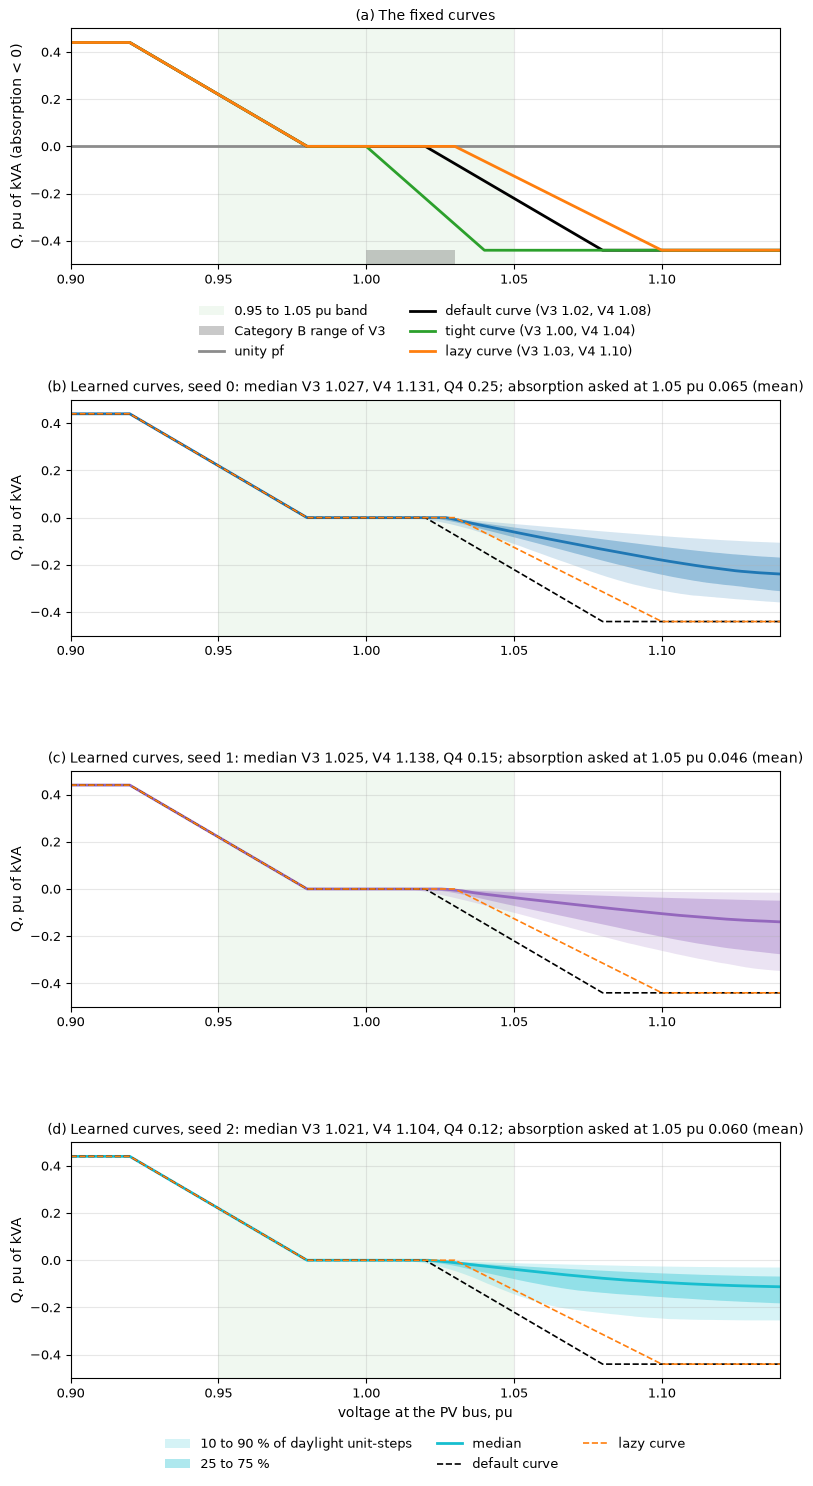

default curve : absorption asked at 1.05 pu = 0.220 pu of kVA
tight curve   : absorption asked at 1.05 pu = 0.440 pu of kVA
lazy curve    : absorption asked at 1.05 pu = 0.126 pu of kVA


In [3]:
def q_curve(v, v3, v4, q4):
    '''Reactive power (pu of kVA, absorption negative) of the full curve at voltage v.'''
    v = np.asarray(v, dtype=float)
    lower = np.interp(v, [0.92, 0.98], [0.44, 0.0])
    upper = -q4 * np.clip((v - v3) / (v4 - v3), 0.0, 1.0)
    return np.where(v < 0.98, lower, np.where(v > v3, upper, 0.0))

FIXED = {"default": (1.02, 1.08, 0.44), "tight": (1.00, 1.04, 0.44), "lazy": (1.03, 1.10, 0.44)}
vg = np.linspace(0.90, 1.14, 481)
rng = np.random.default_rng(0)

fig, axes = plt.subplots(4, 1, figsize=(8, 15))
ax = axes[0]
ax.axvspan(0.95, 1.05, color="tab:green", alpha=0.07, lw=0, label="0.95 to 1.05 pu band")
ax.axvspan(1.00, 1.03, ymin=0.0, ymax=0.06, color="0.4", alpha=0.35, lw=0, label="Category B range of V3")
ax.axhline(0, color=COL["unity"], lw=2, label=NAME["unity"])
for k, c in FIXED.items():
    ax.plot(vg, q_curve(vg, *c), color=COL[k], lw=2, label=f"{NAME[k]} (V3 {c[0]:.2f}, V4 {c[1]:.2f})")
ax.set_xlim(0.90, 1.14); ax.set_ylim(-0.5, 0.5); ax.grid(alpha=0.3)
ax.set_ylabel("Q, pu of kVA (absorption < 0)"); ax.set_title("(a) The fixed curves")
legend_below(ax, ncol=2, dy=-0.12)

band_stats = {}
for ax, s in zip(axes[1:], SEEDS):
    r = Y[f"sac{s}"]
    day = r.irr > 0.05                                        # (steps, units)
    c = r.curves[day]                                          # (n, 3): V3, V4, Q4
    pick = rng.choice(len(c), size=min(20000, len(c)), replace=False)
    Q = np.stack([q_curve(vg, *row) for row in c[pick]])
    p10, p25, p50, p75, p90 = np.percentile(Q, [10, 25, 50, 75, 90], axis=0)
    ax.axvspan(0.95, 1.05, color="tab:green", alpha=0.07, lw=0)
    ax.fill_between(vg, p10, p90, color=COL[f"sac{s}"], alpha=0.18, lw=0, label="10 to 90 % of daylight unit-steps")
    ax.fill_between(vg, p25, p75, color=COL[f"sac{s}"], alpha=0.35, lw=0, label="25 to 75 %")
    ax.plot(vg, p50, color=COL[f"sac{s}"], lw=2, label="median")
    for k in ("default", "lazy"):
        ax.plot(vg, q_curve(vg, *FIXED[k]), color=COL[k], lw=1.2, ls="--", label=NAME[k])
    at105 = -q_curve(1.05, c[:, 0], c[:, 1], c[:, 2])
    band_stats[s] = dict(v3_median=float(np.median(c[:, 0])), v4_median=float(np.median(c[:, 1])),
                         q4_median=float(np.median(c[:, 2])), q_at_105_median=float(np.median(at105)),
                         q_at_105_mean=float(at105.mean()))
    ax.set_xlim(0.90, 1.14); ax.set_ylim(-0.5, 0.5); ax.grid(alpha=0.3); ax.set_ylabel("Q, pu of kVA")
    ax.set_title(f"({'bcd'[s]}) Learned curves, seed {s}: median V3 {band_stats[s]['v3_median']:.3f}, "
                 f"V4 {band_stats[s]['v4_median']:.3f}, Q4 {band_stats[s]['q4_median']:.2f}; "
                 f"absorption asked at 1.05 pu {band_stats[s]['q_at_105_mean']:.3f} (mean)")
axes[3].set_xlabel("voltage at the PV bus, pu")
legend_below(axes[3], ncol=3, dy=-0.2)
plt.tight_layout(); save(fig, "01_curves"); plt.show()
for k, c in FIXED.items():
    print(f"{NAME[k]:14s}: absorption asked at 1.05 pu = {-q_curve(1.05, *c):.3f} pu of kVA")

The learned curves are milder than the default curve, and above about 1.05 pu also milder
than the lazy curve. Their median V3 (1.021 to 1.027 pu) lies between the default and lazy
values, but the slope is much flatter: the median V4 is 1.10 to 1.14 pu and the median Q4 only
0.12 to 0.25 pu of kVA instead of 0.44. At 1.05 pu they ask on average for 0.046 to 0.065 pu
of kVA, where the lazy curve asks for 0.126 and the default curve for 0.22. The bands are
wide because each policy moves its curve with the time of day and the sun. Every learned
curve stays inside the adjustable ranges of the standard (V3 1.00 to 1.03 pu, V4 up to
1.18 pu, Q4 from 0 to 0.44 pu).

## 3. The full year

The headline comparison on all 35,040 steps of 2023. Four quantities: (a) hours with any
feeder-1 bus outside 0.95 to 1.05 pu; (b) feeder losses; (c) reactive energy absorbed by
the nine inverters; (d) the core reward, which weighs all of these (and curtailment) in one
number, higher is better. The learned policies are the kept checkpoints with the fence on;
the black crosses mark the same policies at the end of training. Note that the loss axis
starts at 350 MWh.

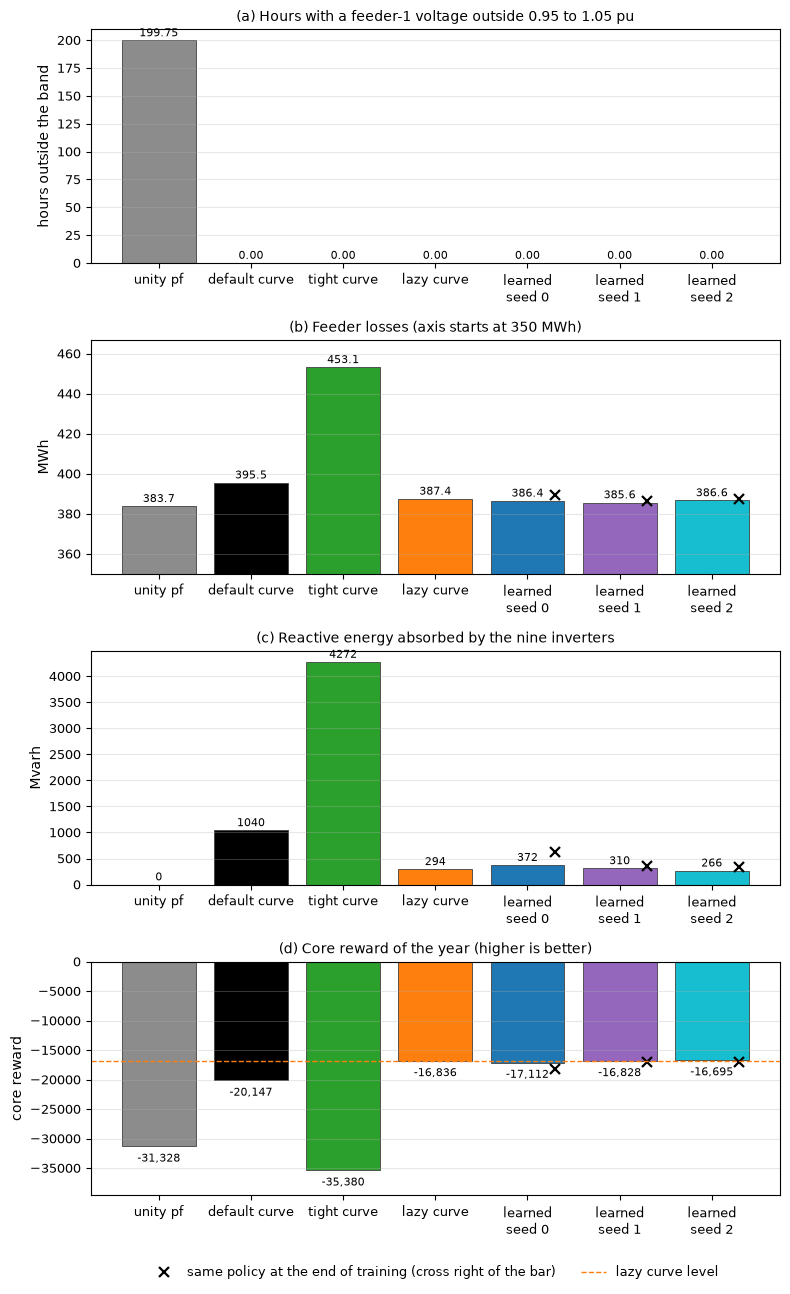

,hours_violation,vmax,losses_mwh,reactive_absorbed_mvarh,reactive_injected_mvarh,curtailed_mwh,fence_steps,fence_mvarh,core_reward
unity pf,199.75,1.0637,383.74,0.0,0.0,0.000,0.0,0.00,-31328.0
default curve,0.00,1.0421,395.52,1040.4,41.1,0.000,0.0,0.00,-20147.0
tight curve,0.00,1.0351,453.15,4272.4,41.1,0.000,0.0,0.00,-35380.0
lazy curve,0.00,1.0485,387.41,293.7,41.1,0.000,0.0,0.00,-16836.0
"learned, seed 0",0.00,1.0500,386.44,372.4,41.1,0.000,36.0,1.35,-17112.0
"learned, seed 1",0.00,1.0500,385.60,309.8,41.1,0.000,130.0,4.17,-16828.0
"learned, seed 2",0.00,1.0500,386.63,266.0,41.1,0.005,79.0,2.94,-16695.0
"learned, seed 0, end of training",0.00,1.0496,389.51,628.2,41.1,0.000,36.0,1.68,-18258.0
"learned, seed 1, end of training",0.00,1.0500,386.35,359.1,41.1,0.000,84.0,2.72,-17055.0
"learned, seed 2, end of training",0.00,1.0499,387.16,338.1,41.1,0.155,66.0,2.56,-17034.0


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(8, 13))
x = np.arange(len(MAIN))
spec = [("hours_violation", "hours outside the band", "(a) Hours with a feeder-1 voltage outside 0.95 to 1.05 pu", "{:.2f}", None),
        ("losses_mwh", "MWh", "(b) Feeder losses (axis starts at 350 MWh)", "{:.1f}", (350, None)),
        ("reactive_absorbed_mvarh", "Mvarh", "(c) Reactive energy absorbed by the nine inverters", "{:.0f}", None),
        ("core_reward", "core reward", "(d) Core reward of the year (higher is better)", "{:,.0f}", None)]
for ax, (key, ylab, title, fmt, ylim) in zip(axes, spec):
    vals = np.array([K[k][key] for k in MAIN])
    bars = ax.bar(x, vals, color=[COL[k] for k in MAIN], edgecolor="0.25", lw=0.6)
    for xi, v in zip(x, vals):
        ax.annotate(fmt.format(v), (xi, v), xytext=(0, 3 if v >= 0 else -11), textcoords="offset points", ha="center", fontsize=8)
    if key != "hours_violation":
        ends = [K[f"end{s}"][key] for s in SEEDS]
        ax.plot(x[4:] + 0.3, ends, "x", color="black", ms=7, mew=1.6, label="same policy at the end of training (cross right of the bar)")
    if ylim:
        ax.set_ylim(ylim[0], max(vals.max(), max(K[f'end{s}'][key] for s in SEEDS)) * 1.03)
    if key == "core_reward":
        ax.axhline(K["lazy"]["core_reward"], color=COL["lazy"], lw=1, ls="--", label="lazy curve level")
        ax.set_ylim(vals.min() * 1.12, 0)
    ax.set_xticks(x); ax.set_xticklabels([NAME[k].replace("learned, ", "learned\n") for k in MAIN])
    ax.set_ylabel(ylab); ax.set_title(title); ax.grid(axis="y", alpha=0.3)
legend_below(axes[3], ncol=2, dy=-0.25)
plt.tight_layout(); save(fig, "02_full_year"); plt.show()

cols = ["hours_violation", "vmax", "losses_mwh", "reactive_absorbed_mvarh", "reactive_injected_mvarh",
        "curtailed_mwh", "fence_steps", "fence_mvarh", "core_reward"]
rows = MAIN + [f"end{s}" for s in SEEDS]
tab_year = pd.DataFrame({Y[k].label: {c: K[k][c] for c in cols} for k in rows}).T
tab_year.round({"hours_violation": 2, "vmax": 4, "losses_mwh": 2, "reactive_absorbed_mvarh": 1, "reactive_injected_mvarh": 1,
                "curtailed_mwh": 3, "fence_mvarh": 2, "core_reward": 0})

All controllers except unity power factor keep every feeder-1 bus inside 0.95 to 1.05 pu for
the whole year. They differ in what that costs.

- The **default curve** raises the losses from 383.7 MWh (unity pf) to 395.5 MWh and absorbs
  1,040 Mvarh. The **tight curve** holds the voltage furthest from the limit at four times
  that reactive energy and 453 MWh of losses.
- The **lazy curve** holds the limit with 294 Mvarh and 387.4 MWh.
- The **learned policies** have the lowest losses of all curve-based controllers (385.6 to
  386.6 MWh) and absorb 266 to 372 Mvarh. Their core reward (-17,112 to -16,695) lies around
  that of the lazy curve (-16,836): one seed is below it, two are above it. They need the
  fence on 36 to 130 steps of the year.
- The same policies at the **end of training** (crosses) are all worse than the lazy curve.
  Keeping the best checkpoint of training matters here as much as the training itself.

## 4. A grid of fixed curves

The lazy curve (V3 1.03, V4 1.10) was chosen by hand in notebook 04 as one milder setting
of the standard. If a slightly different fixed curve does better still, the learned
policies should be compared with that curve, not with one hand pick. The grid below keeps
Q4 at 0.44 and the Category B shape, and varies

- V3 in {1.02, 1.025, 1.03} pu (1.03 is the top of the Category B range), and
- V4 in {1.06, 1.08, 1.10, 1.13, 1.16} pu,

15 curves in all. Each is run on the full year twice:

- **fence off**, exactly as the default, tight and lazy references were: does the fixed
  curve hold the limit by itself?
- **fence on**, exactly as the learned policies run: the fence tops up absorption on any
  step where the curve would let a bus pass 1.05 pu. This is the like-for-like comparison
  with the learned policies, which also run with the fence.

The grid contains the default curve (1.02, 1.08) and the lazy curve (1.03, 1.10), which
serve as a check against section 1. The *best fixed curve + fence* is the grid curve with
the highest core reward when run with the fence. Picking it on 2023 gives it the same
advantage the kept checkpoints have (both are selected on the year they are scored on);
section 11 therefore tests both on a second year.

In [5]:
GRID_V3, GRID_V4 = (1.02, 1.025, 1.03), (1.06, 1.08, 1.10, 1.13, 1.16)
E_off = VoltVarEnv(CFG_OFF, pv=pv, loads=loads)
E_on = VoltVarEnv(CFG, pv=pv, loads=loads)
grid, grid_on, runs_on = {}, {}, {}
t0 = time.perf_counter()
for v3 in GRID_V3:
    for v4 in GRID_V4:
        pol = env.constant_policy(env.curve_to_action(v3, v4, 0.44))
        grid[(v3, v4)] = from_env(E_off.run_policy(pol, label=f"V3 {v3}, V4 {v4}, fence off", verbose=False)).kpis()
        r = from_env(E_on.run_policy(pol, label=f"V3 {v3}, V4 {v4}, fence on", verbose=False))
        grid_on[(v3, v4)] = r.kpis(); runs_on[(v3, v4)] = r
print(f"{2 * len(grid)} full-year runs in {time.perf_counter() - t0:.0f} s")
for key, ref_k in (((1.02, 1.08), "default"), ((1.03, 1.10), "lazy")):
    assert abs(grid[key]["core_reward"] / K[ref_k]["core_reward"] - 1) < 1e-4
print("grid points (1.02, 1.08) and (1.03, 1.10) with the fence off reproduce the default and lazy references")
best_off = max((k for k in grid if grid[k]["hours_violation"] == 0), key=lambda k: grid[k]["core_reward"])
best_key = max(grid_on, key=lambda k: grid_on[k]["core_reward"])
best_run = runs_on[best_key]; del runs_on
best_run.label = f"best fixed curve + fence (V3 {best_key[0]}, V4 {best_key[1]})"
Y["grid"], K["grid"] = best_run, grid_on[best_key]
S["grid"] = best_run.days(SAMPLE_DAYS); KS["grid"] = S["grid"].kpis()
tab_grid = pd.DataFrame([dict(V3=v3, V4=v4, hours_out_fence_off=grid[(v3, v4)]["hours_violation"], vmax_fence_off=grid[(v3, v4)]["vmax"],
                              core_fence_off=grid[(v3, v4)]["core_reward"], fence_steps=k["fence_steps"], fence_mvarh=k["fence_mvarh"],
                              losses_mwh=k["losses_mwh"], Q_abs_mvarh=k["reactive_absorbed_mvarh"], core_fence_on=k["core_reward"])
                         for (v3, v4), k in grid_on.items()])
print(f"best curve that holds the limit without the fence: V3 {best_off[0]}, V4 {best_off[1]} (core reward {grid[best_off]['core_reward']:,.0f})")
print(f"best fixed curve + fence: V3 {best_key[0]}, V4 {best_key[1]}: core reward {K['grid']['core_reward']:,.0f}, "
      f"losses {K['grid']['losses_mwh']:.2f} MWh, absorbed {K['grid']['reactive_absorbed_mvarh']:.1f} Mvarh, "
      f"fence on {K['grid']['fence_steps']} steps ({K['grid']['fence_mvarh']:.2f} Mvarh), {K['grid']['hours_violation']:.2f} h outside the band")
tab_grid.sort_values("core_fence_on", ascending=False).round({"vmax_fence_off": 4, "core_fence_off": 0, "fence_mvarh": 2, "losses_mwh": 2,
                                                             "Q_abs_mvarh": 1, "core_fence_on": 0})

30 full-year runs in 613 s
grid points (1.02, 1.08) and (1.03, 1.10) with the fence off reproduce the default and lazy references
best curve that holds the limit without the fence: V3 1.03, V4 1.1 (core reward -16,836)
best fixed curve + fence: V3 1.03, V4 1.16: core reward -16,405, losses 385.79 MWh, absorbed 202.2 Mvarh, fence on 43 steps (1.33 Mvarh), 0.00 h outside the band


,V3,V4,hours_out_fence_off,vmax_fence_off,core_fence_off,fence_steps,fence_mvarh,losses_mwh,Q_abs_mvarh,core_fence_on
14,1.030,1.16,10.75,1.0534,-16517.0,43,1.33,385.79,202.2,-16405.0
13,1.030,1.13,1.25,1.0514,-16580.0,5,0.14,386.41,238.7,-16576.0
12,1.030,1.10,0.00,1.0485,-16836.0,0,0.00,387.41,293.7,-16836.0
11,1.030,1.08,0.00,1.0457,-17092.0,0,0.00,388.46,347.2,-17092.0
9,1.025,1.16,2.00,1.0520,-17196.0,8,0.23,387.28,381.6,-17182.0
10,1.030,1.06,0.00,1.0417,-17467.0,0,0.00,390.09,424.7,-17467.0
8,1.025,1.13,0.00,1.0499,-17498.0,0,0.00,388.26,450.9,-17498.0
7,1.025,1.10,0.00,1.0468,-17961.0,0,0.00,389.80,551.2,-17961.0
4,1.020,1.16,0.25,1.0508,-18239.0,1,0.03,389.40,624.2,-18237.0
6,1.025,1.08,0.00,1.0439,-18409.0,0,0.00,391.38,647.2,-18409.0


Four views of the grid: (a) losses against absorbed reactive energy with the fence on, the
trade-off every curve makes, with the named curves and the learned policies (hollow
markers: end of training); (b) the core reward over the grid with the fence off, marking
the curves that leave the band; (c) the same with the fence on, with the number of steps
on which the fence acts, the best cell framed; (d) the core reward of the best fixed curve
+ fence, the lazy and default curves and the three learned policies side by side.

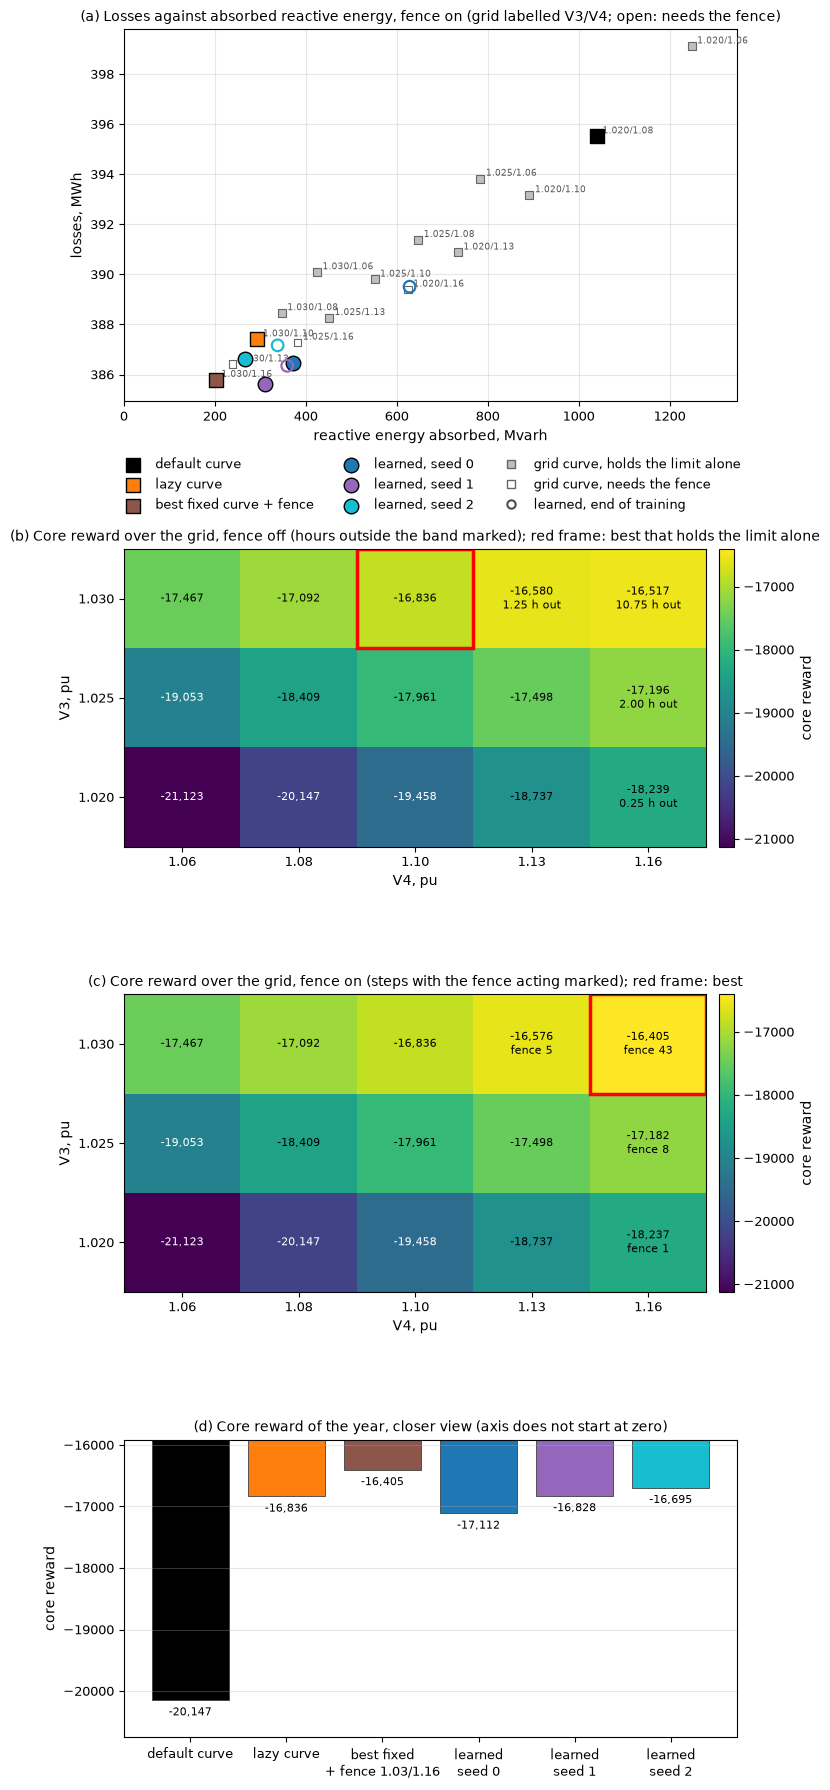

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(8, 18), gridspec_kw=dict(height_ratios=[1.25, 1, 1, 1]))
ax = axes[0]
for (v3, v4), k in grid_on.items():
    needs = grid[(v3, v4)]["hours_violation"] > 0
    ax.scatter(k["reactive_absorbed_mvarh"], k["losses_mwh"], s=30, marker="s", facecolor="none" if needs else "0.75",
               edgecolor="0.4", lw=0.8, zorder=2)
    ax.annotate(f"{v3:.3f}/{v4:.2f}", (k["reactive_absorbed_mvarh"], k["losses_mwh"]), xytext=(4, 2), textcoords="offset points", fontsize=6.5, color="0.35")
for kk in ("default", "lazy", "grid"):
    ax.scatter(K[kk]["reactive_absorbed_mvarh"], K[kk]["losses_mwh"], s=110, marker="s", color=COL[kk], edgecolor="black", zorder=4, label=NAME[kk])
for s in SEEDS:
    ax.scatter(K[f"sac{s}"]["reactive_absorbed_mvarh"], K[f"sac{s}"]["losses_mwh"], s=110, marker="o", color=COL[f"sac{s}"], edgecolor="black", zorder=5, label=NAME[f"sac{s}"])
    ax.scatter(K[f"end{s}"]["reactive_absorbed_mvarh"], K[f"end{s}"]["losses_mwh"], s=70, marker="o", facecolor="none", edgecolor=COL[f"sac{s}"], lw=1.6, zorder=5)
xmax = max(K["default"]["reactive_absorbed_mvarh"], max(k["reactive_absorbed_mvarh"] for k in grid.values())) * 1.08
ax.set_xlim(0, xmax); ax.grid(alpha=0.3)
ax.set_xlabel("reactive energy absorbed, Mvarh"); ax.set_ylabel("losses, MWh")
ax.set_title("(a) Losses against absorbed reactive energy, fence on (grid labelled V3/V4; open: needs the fence)")
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([], [], marker="s", ls="", mfc="0.75", mec="0.4", label="grid curve, holds the limit alone"),
            Line2D([], [], marker="s", ls="", mfc="none", mec="0.4", label="grid curve, needs the fence"),
            Line2D([], [], marker="o", ls="", mfc="none", mec="0.3", mew=1.5, label="learned, end of training")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

Zoff = np.array([[grid[(v3, v4)]["core_reward"] for v4 in GRID_V4] for v3 in GRID_V3])
Zon = np.array([[grid_on[(v3, v4)]["core_reward"] for v4 in GRID_V4] for v3 in GRID_V3])
zmin, zmax = min(Zoff.min(), Zon.min()), max(Zoff.max(), Zon.max())
for ax, Z, G, title, extra, box in (
        (axes[1], Zoff, grid, "(b) Core reward over the grid, fence off (hours outside the band marked)", "hours_violation", best_off),
        (axes[2], Zon, grid_on, "(c) Core reward over the grid, fence on (steps with the fence acting marked)", "fence_steps", best_key)):
    im = ax.imshow(Z, cmap="viridis", aspect="auto", origin="lower", vmin=zmin, vmax=zmax)
    for i, v3 in enumerate(GRID_V3):
        for j, v4 in enumerate(GRID_V4):
            k = G[(v3, v4)]
            note = (f"\n{k['hours_violation']:.2f} h out" if extra == "hours_violation" else f"\nfence {k['fence_steps']}") if k[extra] > 0 else ""
            ax.text(j, i, f"{k['core_reward']:,.0f}" + note, ha="center", va="center", fontsize=8,
                    color="white" if Z[i, j] < (zmin + zmax) / 2 else "black")
    bi, bj = GRID_V3.index(box[0]), GRID_V4.index(box[1])
    ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, ec="red", lw=2.5))
    ax.set_xticks(range(len(GRID_V4))); ax.set_xticklabels([f"{v:.2f}" for v in GRID_V4]); ax.set_xlabel("V4, pu")
    ax.set_yticks(range(len(GRID_V3))); ax.set_yticklabels([f"{v:.3f}" for v in GRID_V3]); ax.set_ylabel("V3, pu")
    ax.set_title(title + "; red frame: best" + (" that holds the limit alone" if extra == "hours_violation" else ""))
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="core reward")

ax = axes[3]
keys = ["default", "lazy", "grid", "sac0", "sac1", "sac2"]
vals = [K[k]["core_reward"] for k in keys]
ax.bar(range(len(keys)), vals, color=[COL[k] for k in keys], edgecolor="0.25", lw=0.6)
for i, v in enumerate(vals):
    ax.annotate(f"{v:,.0f}", (i, v), xytext=(0, -11), textcoords="offset points", ha="center", fontsize=8)
lo = min(vals) * 1.03; hi = max(vals) * 0.97
ax.set_ylim(lo, hi); ax.set_xticks(range(len(keys)))
ax.set_xticklabels([NAME[k].replace("learned, ", "learned\n").replace("best fixed curve + fence", f"best fixed\n+ fence {best_key[0]}/{best_key[1]}") for k in keys])
ax.set_ylabel("core reward"); ax.grid(axis="y", alpha=0.3)
ax.set_title("(d) Core reward of the year, closer view (axis does not start at zero)")
plt.tight_layout(); save(fig, "03_fixed_curve_grid"); plt.show()

The grid gives two answers, one per column of the table.

**Without the fence**, the best curve that holds the limit by itself is the lazy curve
(1.03, 1.10). Milder curves score a higher core reward but leave the band: 1.25 h for
(1.03, 1.13) and 10.75 h for (1.03, 1.16). The reward's voltage term (1,000 per pu of excess)
is too weak to forbid small excursions: a bus 0.003 pu above the limit for one step costs 3,
less than the reactive power saved on that step. The reward therefore ranks some curves that
break the limit above curves that keep it, and a limit that must hold cannot be left to the
reward alone.

**With the fence**, which is how the learned policies run, the mildest curve of the grid,
V3 1.03 and V4 1.16, scores -16,405: better than every learned policy (-17,112 to -16,695) and
than the lazy curve. The fence acts on 43 steps (1.33 Mvarh), within the range of the learned
policies (36 to 130 steps). Its losses equal those of the learned policies (385.8 MWh), and it
absorbs less reactive energy (202 Mvarh against 266 to 372).

Panel (a) shows why. All curves, fixed and learned, lie close to one line: losses fall as
absorbed energy falls. The learned policies sit on that line, not below it. Their
time-varying curves do not reach a combination of losses and reactive energy that a fixed
curve cannot.

## 5. Voltage: duration curves of the feeder maximum

For each controller, the maximum of the eleven feeder-1 voltages at each step, sorted from
the highest down: (a) the whole year, (b) the 400 highest hours. A controller that holds
the limit bends its curve under 1.05 pu; how far under it stays is the reactive power it
spends for nothing.

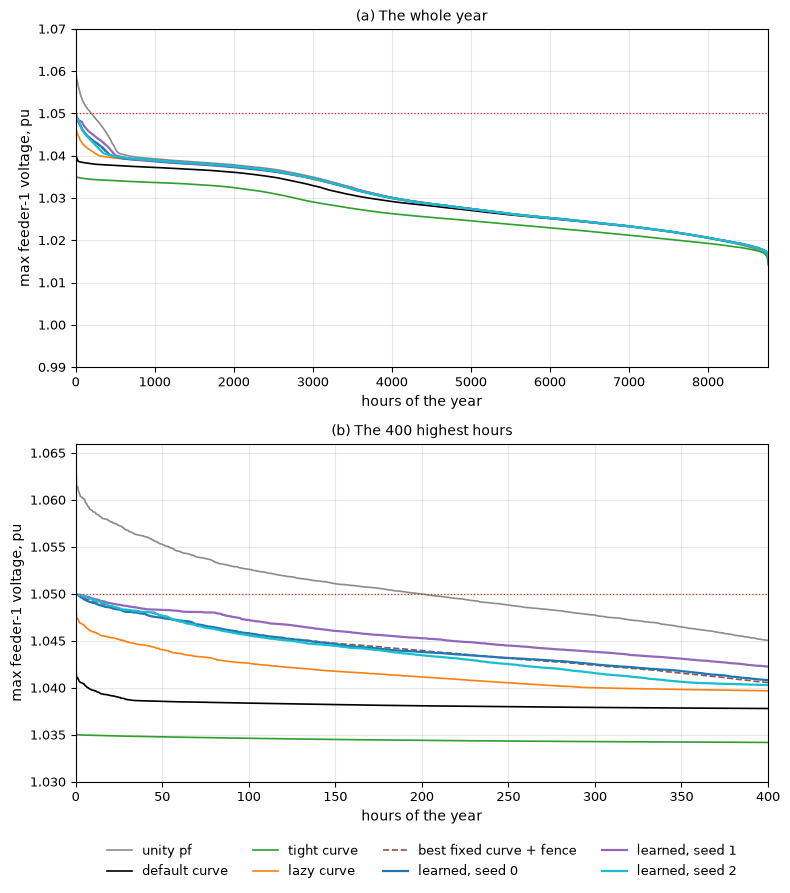

unity pf                         max 1.0637 pu | hours above 1.045 pu 401.00 | above 1.05 pu 199.75
default curve                    max 1.0421 pu | hours above 1.045 pu   0.00 | above 1.05 pu   0.00
tight curve                      max 1.0351 pu | hours above 1.045 pu   0.00 | above 1.05 pu   0.00
lazy curve                       max 1.0485 pu | hours above 1.045 pu  28.00 | above 1.05 pu   0.00
best fixed curve + fence         max 1.0500 pu | hours above 1.045 pu 136.75 | above 1.05 pu   0.00
learned, seed 0                  max 1.0500 pu | hours above 1.045 pu 134.50 | above 1.05 pu   0.00
learned, seed 1                  max 1.0500 pu | hours above 1.045 pu 216.75 | above 1.05 pu   0.00
learned, seed 2                  max 1.0500 pu | hours above 1.045 pu 124.25 | above 1.05 pu   0.00


In [7]:
keys = ["unity", "default", "tight", "lazy", "grid", "sac0", "sac1", "sac2"]
fig, axes = plt.subplots(2, 1, figsize=(8, 9))
for ax, (xlim, ylim, title) in zip(axes, (((0, 8760), (0.99, 1.07), "(a) The whole year"),
                                          ((0, 400), (1.03, 1.066), "(b) The 400 highest hours"))):
    for k in keys:
        dur = np.sort(Y[k].v.max(axis=1))[::-1]
        ax.plot(np.arange(1, len(dur) + 1) * DT_H, dur, color=COL[k], lw=1.6 if k.startswith("sac") else 1.2,
                ls="--" if k == "grid" else "-", label=NAME[k])
    ax.axhline(1.05, color="tab:red", lw=0.9, ls=":")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.grid(alpha=0.3)
    ax.set_xlabel("hours of the year"); ax.set_ylabel("max feeder-1 voltage, pu"); ax.set_title(title)
legend_below(axes[1], ncol=4, dy=-0.15)
plt.tight_layout(); save(fig, "04_duration"); plt.show()
for k in keys:
    vm = Y[k].v.max(axis=1)
    print(f"{NAME[k]:32s} max {vm.max():.4f} pu | hours above 1.045 pu {np.sum(vm > 1.045) * DT_H:6.2f} | above 1.05 pu {np.sum(vm > 1.05) * DT_H:6.2f}")

The default and tight curves keep the feeder maximum well below the limit (1.042 and
1.035 pu at most), and that margin is paid for in reactive energy. The lazy curve reaches
1.0485 pu. The learned policies and the best fixed curve + fence use the band to its edge:
the maximum sits at 1.050 pu, above 1.045 pu for 124 to 217 hours, with the fence taking the
last step on the few steps where the curve alone would pass the limit.

## 6. When the reactive energy is spent

The total reactive power absorbed by the nine units at every step of the year, as a map
with the day of the year upwards and the hour of the day across, for (a) the default curve,
(b) the lazy curve and (c) the learned policy with the best core reward. All three maps use
the same colour scale.

A second figure shows, per month, (a) the reactive energy absorbed and (b) the change in
losses against the default curve (the tight curve is left out of (b); its losses are far
higher), and (c) how the absorbed energy of the year splits between the hours with PV
output and the night. In this model the inverters stay connected at night and keep
following their curve with zero active power (the OpenDSS inverter model keeps its
reactive capability when the PV output is zero), so a curve whose V3 lies below the
night-time voltage of its bus absorbs all night.

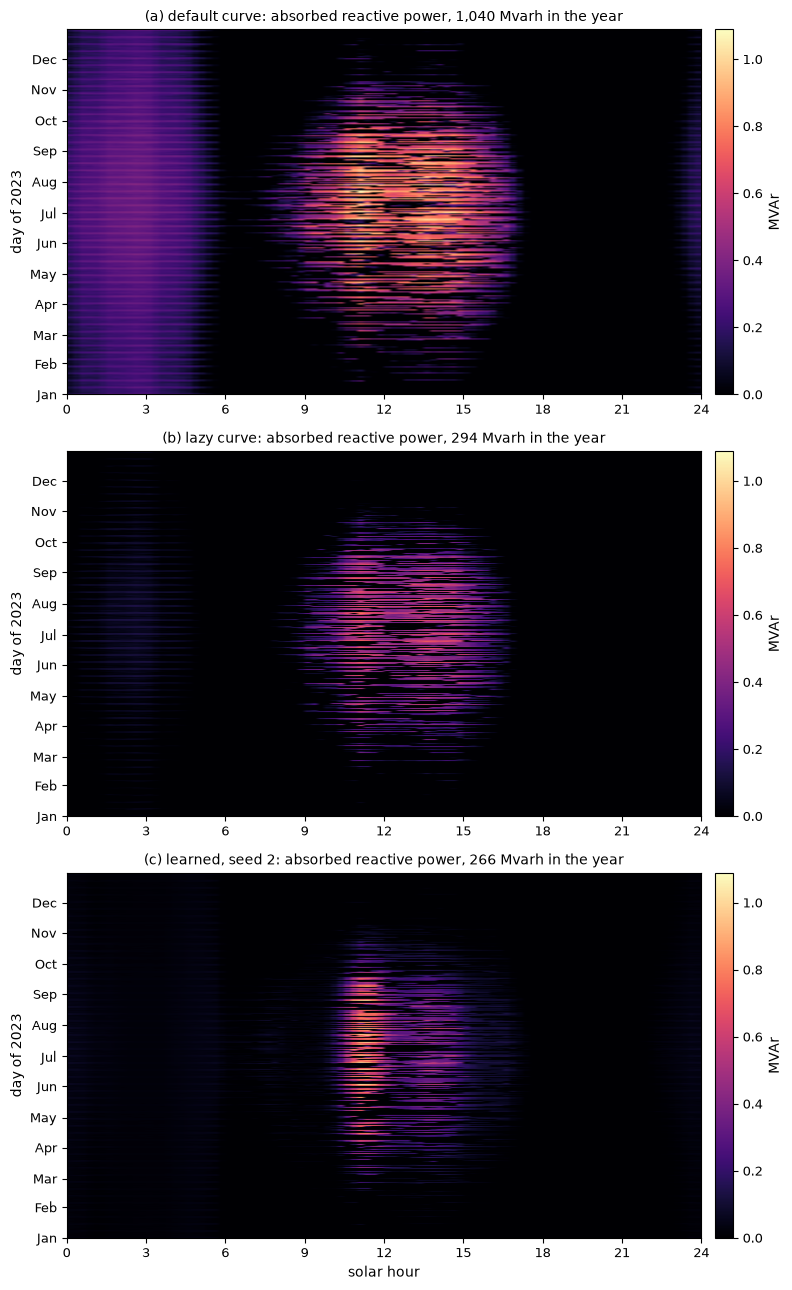

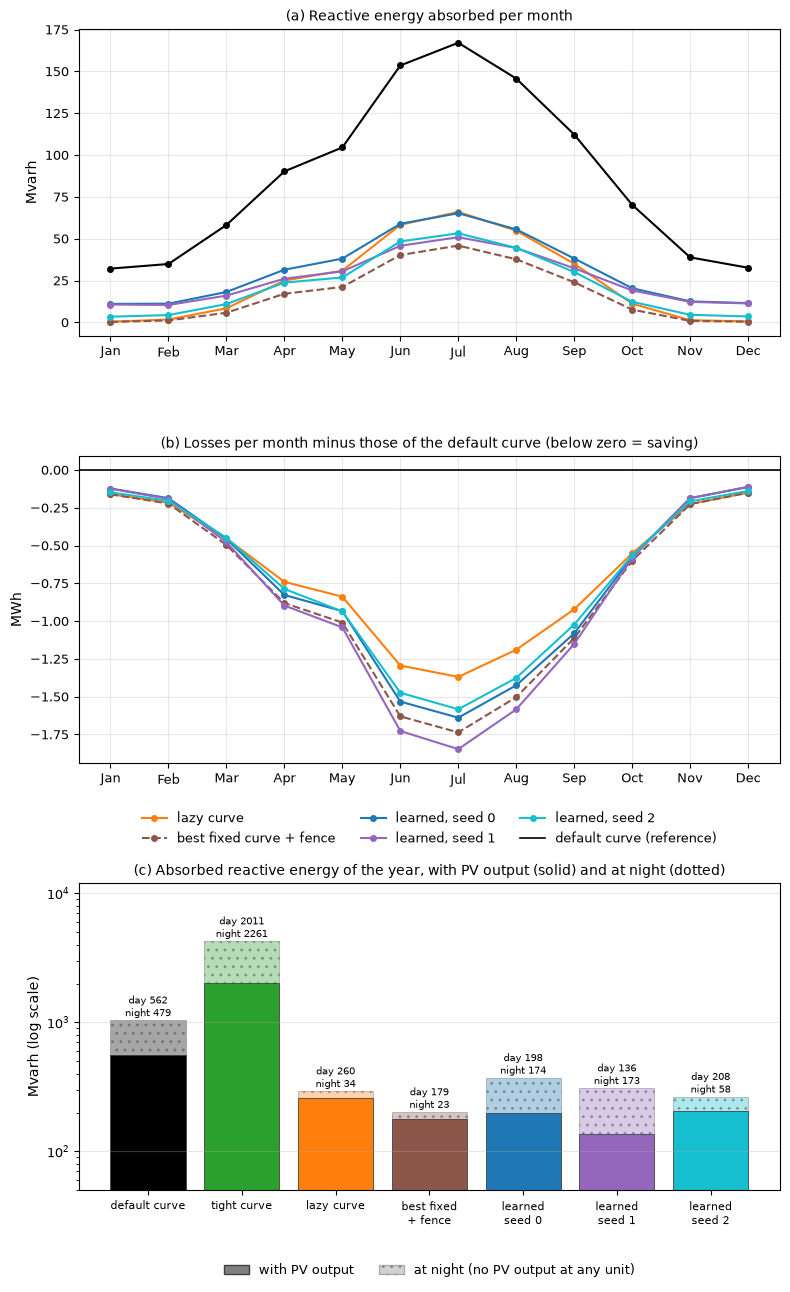

default curve              absorbed with PV output   561.6 Mvarh, at night  478.8 Mvarh (46%)
tight curve                absorbed with PV output  2011.4 Mvarh, at night 2261.0 Mvarh (53%)
lazy curve                 absorbed with PV output   259.9 Mvarh, at night   33.8 Mvarh (12%)
best fixed curve + fence   absorbed with PV output   179.3 Mvarh, at night   22.9 Mvarh (11%)
learned, seed 0            absorbed with PV output   198.3 Mvarh, at night  174.1 Mvarh (47%)
learned, seed 1            absorbed with PV output   136.4 Mvarh, at night  173.3 Mvarh (56%)
learned, seed 2            absorbed with PV output   207.8 Mvarh, at night   58.2 Mvarh (22%)


In [8]:
best_seed = max(SEEDS, key=lambda s: K[f"sac{s}"]["core_reward"])
maps = {k: Y[k].q_abs().sum(axis=1).reshape(365, SPD) / 1e3 for k in ("default", "lazy", f"sac{best_seed}")}
vmax_map = max(m.max() for m in maps.values())
month_start = pd.date_range(f"{YEAR}-01-01", periods=12, freq="MS").dayofyear.values
fig, axes = plt.subplots(3, 1, figsize=(8, 13))
for ax, (k, m), tag in zip(axes, maps.items(), "abc"):
    im = ax.imshow(m, aspect="auto", origin="lower", extent=[0, 24, 1, 365], cmap="magma", vmin=0, vmax=vmax_map)
    ax.set_yticks(month_start); ax.set_yticklabels(MONTHS); ax.set_xticks(range(0, 25, 3))
    ax.set_ylabel(f"day of {YEAR}")
    ax.set_title(f"({tag}) {NAME[k]}: absorbed reactive power, {m.sum() * DT_H:,.0f} Mvarh in the year")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="MVAr")
axes[2].set_xlabel("solar hour")
plt.tight_layout(); save(fig, "05_q_maps"); plt.show()

month = pv.index.month.values
keys = ["default", "lazy", "grid", "sac0", "sac1", "sac2"]
fig, axes = plt.subplots(3, 1, figsize=(8, 13))
ax = axes[0]
for k in keys:
    mq = np.array([Y[k].q_abs()[month == m].sum() * DT_H / 1e3 for m in range(1, 13)])
    ax.plot(range(12), mq, marker="o", ms=4, color=COL[k], ls="--" if k == "grid" else "-", label=NAME[k])
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS); ax.set_ylabel("Mvarh"); ax.grid(alpha=0.3)
ax.set_title("(a) Reactive energy absorbed per month")
ax = axes[1]
ml_def = np.array([Y["default"].losses[month == m].sum() * DT_H / 1e3 for m in range(1, 13)])
for k in keys[1:]:
    ml = np.array([Y[k].losses[month == m].sum() * DT_H / 1e3 for m in range(1, 13)])
    ax.plot(range(12), ml - ml_def, marker="o", ms=4, color=COL[k], ls="--" if k == "grid" else "-", label=NAME[k])
ax.axhline(0, color=COL["default"], lw=1.2, label="default curve (reference)")
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS); ax.set_ylabel("MWh"); ax.grid(alpha=0.3)
ax.set_title("(b) Losses per month minus those of the default curve (below zero = saving)")
legend_below(ax, ncol=3, dy=-0.12)

ax = axes[2]
keys_c = ["default", "tight", "lazy", "grid", "sac0", "sac1", "sac2"]
night_split = {}
for i, k in enumerate(keys_c):
    night = Y[k].p_avail.sum(axis=1) == 0                     # no PV output at any unit
    qa = Y[k].q_abs().sum(axis=1) * DT_H / 1e3
    night_split[k] = dict(day=float(qa[~night].sum()), night=float(qa[night].sum()))
    ax.bar(i, night_split[k]["day"], color=COL[k], edgecolor="0.25", lw=0.6)
    ax.bar(i, night_split[k]["night"], bottom=night_split[k]["day"], color=COL[k], alpha=0.35, hatch="..", edgecolor="0.25", lw=0.6)
    ax.annotate(f"day {night_split[k]['day']:.0f}\nnight {night_split[k]['night']:.0f}", (i, sum(night_split[k].values())),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=7.5)
ax.set_xticks(range(len(keys_c)))
ax.set_xticklabels([NAME[k].replace("learned, ", "learned\n").replace("best fixed curve + fence", "best fixed\n+ fence") for k in keys_c], fontsize=8)
ax.set_yscale("log"); ax.set_ylim(50, 12000); ax.set_ylabel("Mvarh (log scale)"); ax.grid(axis="y", alpha=0.3)
ax.set_title("(c) Absorbed reactive energy of the year, with PV output (solid) and at night (dotted)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, fc="0.5", ec="0.25"), plt.Rectangle((0, 0), 1, 1, fc="0.5", alpha=0.35, hatch="..", ec="0.25")],
          labels=["with PV output", "at night (no PV output at any unit)"], loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
plt.tight_layout(); save(fig, "06_months"); plt.show()
for k, v in night_split.items():
    print(f"{NAME[k]:26s} absorbed with PV output {v['day']:7.1f} Mvarh, at night {v['night']:6.1f} Mvarh ({v['night'] / (v['day'] + v['night']):.0%})")

The maps show where the reactive energy goes. The default curve absorbs at midday on every
sunny day from March to October, and also through many nights. The lazy curve absorbs only
around midday in the sunny half of the year. The learned policy absorbs less than either at
midday, but keeps a thin band of absorption through the night.

Panel (c) of the second figure puts numbers on this. Of the default curve's 1,040 Mvarh, 479
are absorbed at night, when no PV unit produces anything. At light load the feeder voltage
sits around 1.02 to 1.04 pu, above the default V3 of 1.02. The two curves with V3 = 1.03
absorb little at night. The learned policies absorb 58 to 174 Mvarh at night, 22 to 56 % of
their total. They have not learned to switch absorption off when there is nothing to
correct, even though that costs reward on every night step. With PV output, the learned
policies absorb 136 to 208 Mvarh, less than the lazy curve (260 Mvarh).

Panel (b): all milder curves save most losses in June and July, where the default curve
absorbs most, and the learned policies save about as much as the best fixed curve + fence.
Panel (a) shows the night absorption as the winter floor of 10 to 12 Mvarh per month for
seeds 0 and 1.

## 7. Where the reactive energy is spent

Which of the nine units absorbs, ordered by their distance from bus 1 along the feeder:
(a) the reactive energy each unit absorbs over the year; (b) each unit's share of the
absorbed energy on the 32 sampled days, where the OPF bound is available. The OPF knows
every bus voltage and puts its absorption where it moves the highest bus most; a unit
that sees only its own bus has to infer that from its voltage alone.

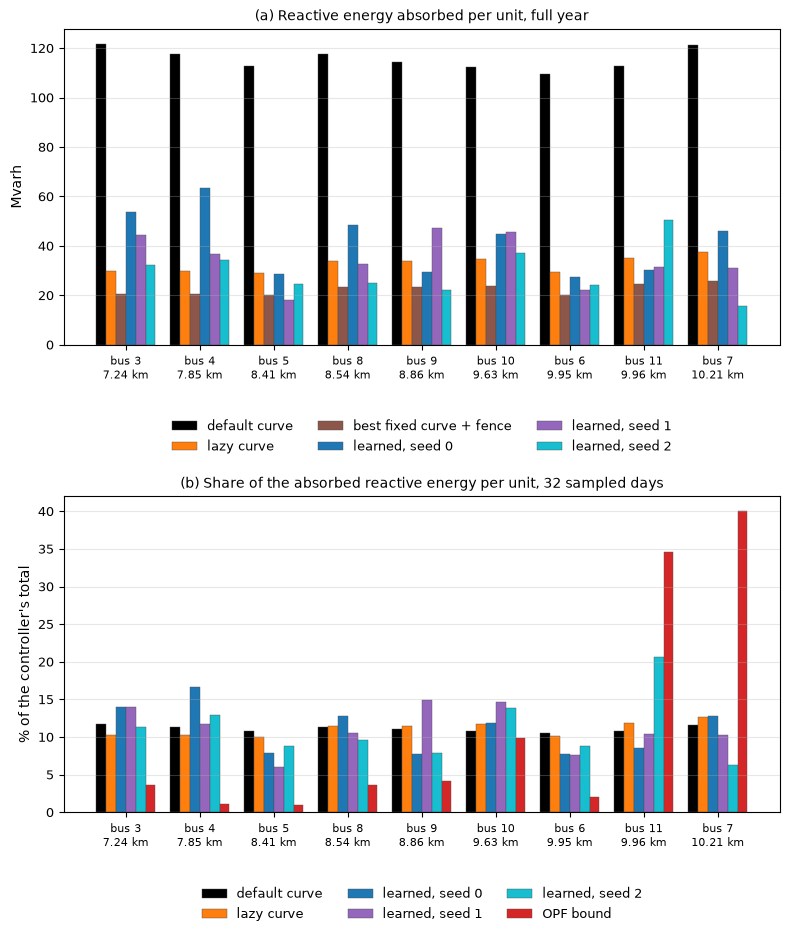

default curve    sampled days: share at buses 7, 10, 11 =  33.3 %, rank correlation of absorbed energy per kVA with distance -0.62
lazy curve       sampled days: share at buses 7, 10, 11 =  36.3 %, rank correlation of absorbed energy per kVA with distance +0.63
learned, seed 0  sampled days: share at buses 7, 10, 11 =  33.2 %, rank correlation of absorbed energy per kVA with distance -0.45
learned, seed 1  sampled days: share at buses 7, 10, 11 =  35.1 %, rank correlation of absorbed energy per kVA with distance -0.43
learned, seed 2  sampled days: share at buses 7, 10, 11 =  40.8 %, rank correlation of absorbed energy per kVA with distance -0.28
OPF bound        sampled days: share at buses 7, 10, 11 =  84.5 %, rank correlation of absorbed energy per kVA with distance +0.68


In [9]:
keys_a = ["default", "lazy", "grid", "sac0", "sac1", "sac2"]
keys_b = ["default", "lazy", "sac0", "sac1", "sac2", "opf"]
xt = [f"bus {PV_BUSES[j]}\n{DIST_KM[j]:.2f} km" for j in JJ]
fig, axes = plt.subplots(2, 1, figsize=(8, 9.5))
for ax, keys, data, title, ylab in (
        (axes[0], keys_a, Y, "(a) Reactive energy absorbed per unit, full year", "Mvarh"),
        (axes[1], keys_b, S, "(b) Share of the absorbed reactive energy per unit, 32 sampled days", "% of the controller's total")):
    w = 0.8 / len(keys)
    for i, k in enumerate(keys):
        e = data[k].q_abs().sum(axis=0) * DT_H / 1e3
        y = e if ax is axes[0] else 100 * e / e.sum()
        ax.bar(np.arange(9) + (i - (len(keys) - 1) / 2) * w, y[JJ], w, color=COL[k], edgecolor="0.3", lw=0.3, label=NAME[k])
    ax.set_xticks(range(9)); ax.set_xticklabels(xt, fontsize=8); ax.set_ylabel(ylab); ax.grid(axis="y", alpha=0.3); ax.set_title(title)
    legend_below(ax, ncol=3, dy=-0.2)
plt.tight_layout(); save(fig, "07_units"); plt.show()

far = [PV_BUSES.index(b) for b in (7, 10, 11)]
for k in keys_b:
    e = S[k].q_abs().sum(axis=0)
    rho = pd.Series(e / PV_KVA).rank().corr(pd.Series(DIST_KM).rank())
    print(f"{NAME[k]:16s} sampled days: share at buses 7, 10, 11 = {100 * e[far].sum() / e.sum():5.1f} %, "
          f"rank correlation of absorbed energy per kVA with distance {rho:+.2f}")

(a) The default curve absorbs almost evenly at all nine units (110 to 122 Mvarh each):
every PV bus of feeder 1 spends many hours above its V3 of 1.02 pu. The learned policies
spread their absorption unevenly, but not by position, and each seed favours different units
(seed 0 bus 4, seed 2 bus 11).

(b) On the sampled days the OPF puts 84.5 % of its absorption at buses 7, 10 and 11, the far
ends of the two laterals, and 40 % at bus 7 alone. A unit there moves the highest voltage of
the feeder most per kvar. The local controllers put 33 to 41 % there. A fixed curve absorbs
more where the voltage is higher, so the lazy curve's absorption per kVA rises with the
distance from the substation (rank correlation +0.63, OPF +0.68). The learned policies lose
this ordering (-0.28 to -0.45): they absorb relatively more near the substation, where it
helps least.

## 8. Two days hour by hour

The worst day of the year, 2023-07-22 (a clear Saturday in July: full sun on a weekend
load), and the typical sunny day, 2023-09-14, both of which are among the sampled days, so
the OPF bound is shown too. Per day: (a) the maximum feeder-1 voltage; (b) the total
reactive power absorbed; (c) the losses minus those of the default curve at the same step.

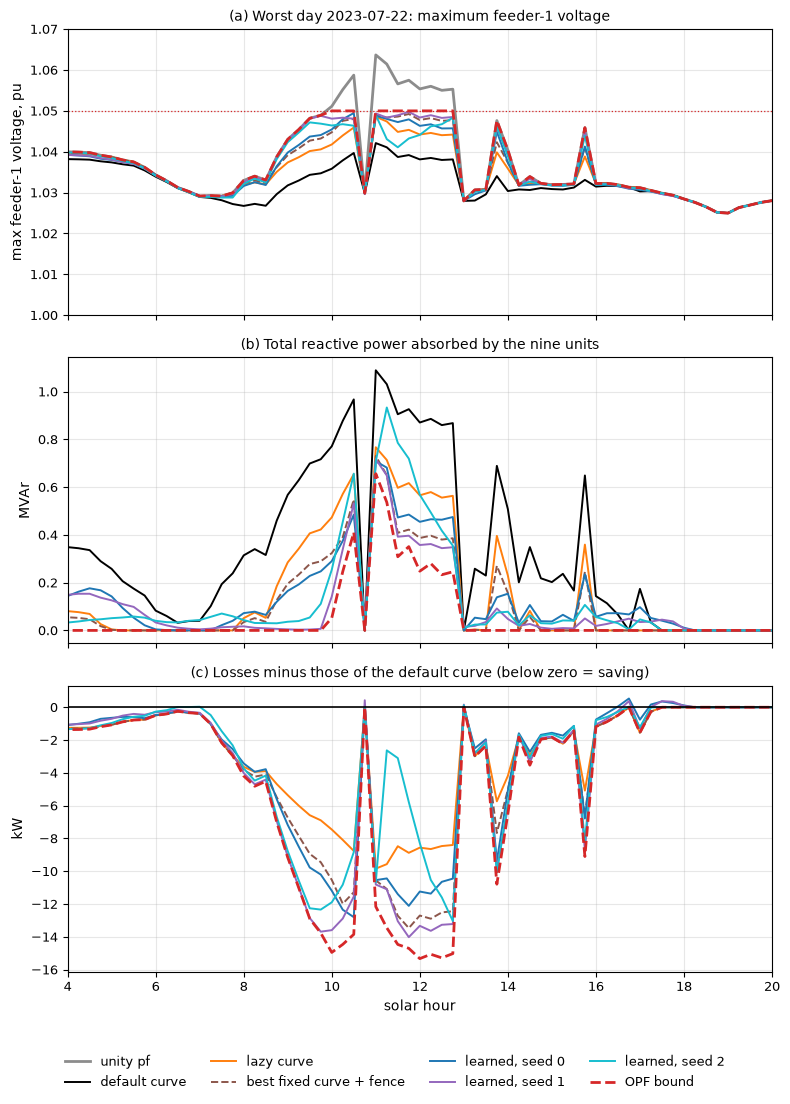

Worst day 2023-07-22, daily totals:
  unity pf                         max 1.0637 pu, 2.75 h out, losses   866.3 kWh, absorbed   0.00 Mvarh, core reward   -545.9
  default curve                    max 1.0421 pu, 0.00 h out, losses   960.8 kWh, absorbed   6.91 Mvarh, core reward    -66.1
  lazy curve                       max 1.0485 pu, 0.00 h out, losses   907.8 kWh, absorbed   2.80 Mvarh, core reward    -47.5
  best fixed curve + fence         max 1.0492 pu, 0.00 h out, losses   894.8 kWh, absorbed   2.03 Mvarh, core reward    -43.9
  learned, seed 0                  max 1.0495 pu, 0.00 h out, losses   898.9 kWh, absorbed   2.78 Mvarh, core reward    -47.1
  learned, seed 1                  max 1.0497 pu, 0.00 h out, losses   890.0 kWh, absorbed   2.15 Mvarh, core reward    -44.2
  learned, seed 2                  max 1.0490 pu, 0.00 h out, losses   901.2 kWh, absorbed   2.27 Mvarh, core reward    -45.1
  OPF bound                        max 1.0500 pu, 0.00 h out, losses   881.8 kWh, 

In [10]:
def day_figure(d, title, name):
    keys = ["unity", "default", "lazy", "grid", "sac0", "sac1", "sac2", "opf"]
    runs = {k: (S[k] if k == "opf" else Y[k]).days([d]) for k in keys}
    assert all(len(r.steps) == SPD for r in runs.values())
    fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)
    for k, r in runs.items():
        style = dict(color=COL[k], lw=2.0 if k in ("opf", "unity") else 1.4, ls="--" if k in ("grid", "opf") else "-", label=NAME[k])
        axes[0].plot(h, r.v.max(axis=1), **style)
        if k != "unity":
            axes[1].plot(h, r.q_abs().sum(axis=1) / 1e3, **style)
        if k not in ("unity", "default"):
            axes[2].plot(h, r.losses - runs["default"].losses, **style)
    axes[0].axhline(1.05, color="tab:red", lw=0.9, ls=":")
    axes[0].set_ylabel("max feeder-1 voltage, pu"); axes[0].set_ylim(1.00, 1.07)
    axes[0].set_title(f"(a) {title}: maximum feeder-1 voltage")
    axes[1].set_ylabel("MVAr"); axes[1].set_title("(b) Total reactive power absorbed by the nine units")
    axes[2].axhline(0, color=COL["default"], lw=1.2)
    axes[2].set_ylabel("kW"); axes[2].set_title("(c) Losses minus those of the default curve (below zero = saving)")
    axes[2].set_xlabel("solar hour"); axes[2].set_xlim(4, 20); axes[2].set_xticks(range(4, 21, 2))
    for ax in axes:
        ax.grid(alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.005))
    plt.tight_layout(rect=(0, 0.06, 1, 1)); save(fig, name); plt.show()
    print(f"{title}, daily totals:")
    for k, r in runs.items():
        kk = r.kpis()
        print(f"  {NAME[k]:32s} max {kk['vmax']:.4f} pu, {kk['hours_violation']:.2f} h out, losses {kk['losses_mwh'] * 1e3:7.1f} kWh, "
              f"absorbed {kk['reactive_absorbed_mvarh']:6.2f} Mvarh, core reward {kk['core_reward']:8.1f}")

day_figure(D_WORST, f"Worst day {sel['worst_day']}", "08_worst_day")

On the worst day, unity power factor leaves the band for 2.75 h, up to 1.064 pu. The default
curve absorbs up to 1.1 MVAr and keeps the maximum at 1.042 pu. The OPF absorbs only between
about 10:00 and 13:00, 0.89 Mvarh in the day, holds the feeder maximum exactly at 1.050 pu and
has the lowest losses. The learned policies and the best fixed curve + fence absorb 2.0 to
2.8 Mvarh and stay within 1.049 to 1.050 pu.

Core reward of the day: OPF -38.8, best fixed curve + fence -43.9, learned -44.2 to -47.1,
lazy -47.5, default -66.1. The dip at 10:45 and the spikes at 13:45 and 15:45 are cloud
passages; every curve follows them within the same step. Before 07:00 the default curve and
the learned policies absorb 0.15 to 0.35 MVAr with no PV output; this is the night
absorption of section 6.

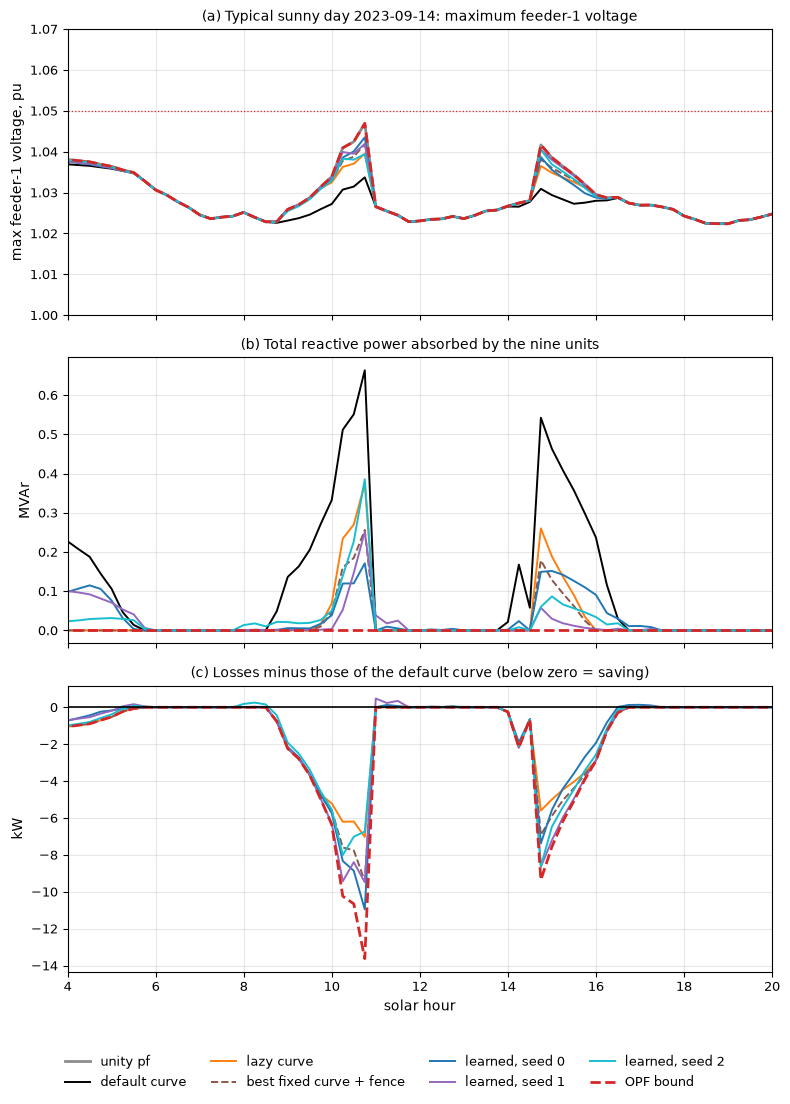

Typical sunny day 2023-09-14, daily totals:
  unity pf                         max 1.0469 pu, 0.00 h out, losses   817.9 kWh, absorbed   0.00 Mvarh, core reward    -32.7
  default curve                    max 1.0377 pu, 0.00 h out, losses   847.5 kWh, absorbed   2.73 Mvarh, core reward    -44.8
  lazy curve                       max 1.0395 pu, 0.00 h out, losses   824.5 kWh, absorbed   0.48 Mvarh, core reward    -34.9
  best fixed curve + fence         max 1.0419 pu, 0.00 h out, losses   822.2 kWh, absorbed   0.33 Mvarh, core reward    -34.2
  learned, seed 0                  max 1.0435 pu, 0.00 h out, losses   824.0 kWh, absorbed   0.84 Mvarh, core reward    -36.3
  learned, seed 1                  max 1.0419 pu, 0.00 h out, losses   822.0 kWh, absorbed   0.66 Mvarh, core reward    -35.5
  learned, seed 2                  max 1.0405 pu, 0.00 h out, losses   823.5 kWh, absorbed   0.50 Mvarh, core reward    -34.9
  OPF bound                        max 1.0469 pu, 0.00 h out, losses   817

In [11]:
day_figure(D_TYP, f"Typical sunny day {sel['typical_day']}", "09_typical_day")

On the typical sunny day, no bus would pass 1.05 pu even at unity power factor (maximum
1.0469 pu). The best action is to do nothing, and the OPF does exactly that: its reward
equals the unity-pf reward, -32.7. Every curve absorbs something. The default curve absorbs
2.73 Mvarh for nothing, the lazy curve 0.48, the best fixed curve + fence 0.33 and the
learned policies 0.50 to 0.84. A controller that knew the voltage would stay inside the band
all day would not absorb at all. A local curve cannot know that.

## 9. The sampled days: distance to the OPF bound

On the 32 sampled days every controller can be placed between the default curve and the
OPF bound (the per-step OPF that maximises the same core reward with knowledge of every
bus). Panel (a) shows the core reward of each controller on these days; panel (b) the
share of the default-to-OPF gap that each closes, per quantity:

$$
\text{gap closed} = \frac{x_\text{controller} - x_\text{default}}{x_\text{OPF} - x_\text{default}},
$$

so 0 is the default curve, 1 (100 %) the bound.

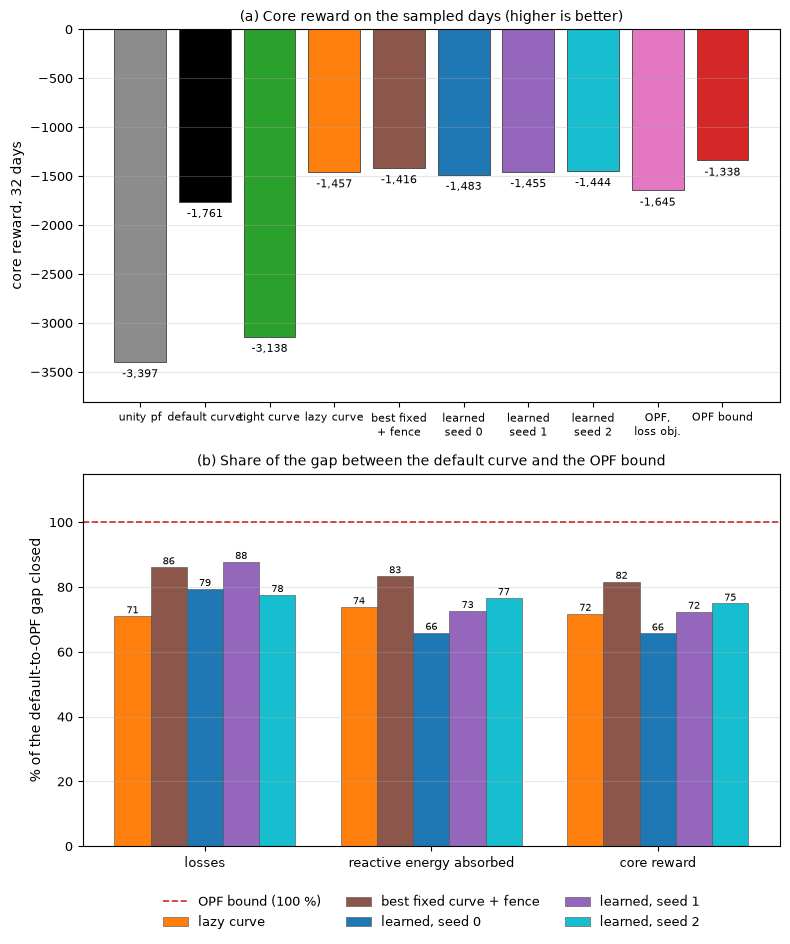

,losses,reactive energy absorbed,core reward
lazy,71.1,73.9,71.8
grid,86.2,83.4,81.7
sac0,79.5,66.0,65.7
sac1,87.8,72.7,72.4
sac2,77.6,76.7,75.0


In [12]:
keys = ["unity", "default", "tight", "lazy", "grid", "sac0", "sac1", "sac2", "opf_loss", "opf"]
fig, axes = plt.subplots(2, 1, figsize=(8, 9.5))
ax = axes[0]
vals = [KS[k]["core_reward"] for k in keys]
ax.bar(range(len(keys)), vals, color=[COL[k] for k in keys], edgecolor="0.25", lw=0.6)
for i, v in enumerate(vals):
    ax.annotate(f"{v:,.0f}", (i, v), xytext=(0, -11), textcoords="offset points", ha="center", fontsize=8)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels([NAME[k].replace("learned, ", "learned\n").replace("best fixed curve + fence", "best fixed\n+ fence").replace("OPF, loss objective", "OPF,\nloss obj.") for k in keys], fontsize=8)
ax.set_ylim(min(vals) * 1.12, 0); ax.set_ylabel("core reward, 32 days"); ax.grid(axis="y", alpha=0.3)
ax.set_title("(a) Core reward on the sampled days (higher is better)")

ax = axes[1]
qty = [("losses_mwh", "losses"), ("reactive_absorbed_mvarh", "reactive energy absorbed"), ("core_reward", "core reward")]
keys_g = ["lazy", "grid", "sac0", "sac1", "sac2"]
gap = {k: {lab: (KS[k][q] - KS["default"][q]) / (KS["opf"][q] - KS["default"][q]) for q, lab in qty} for k in keys_g}
w = 0.8 / len(keys_g)
for i, k in enumerate(keys_g):
    y = [100 * gap[k][lab] for _, lab in qty]
    xs = np.arange(3) + (i - (len(keys_g) - 1) / 2) * w
    ax.bar(xs, y, w, color=COL[k], edgecolor="0.3", lw=0.4, label=NAME[k])
    for xx, yy in zip(xs, y):
        ax.annotate(f"{yy:.0f}", (xx, yy), xytext=(0, 2), textcoords="offset points", ha="center", fontsize=7)
ax.axhline(100, color=COL["opf"], lw=1.2, ls="--", label="OPF bound (100 %)")
ax.set_xticks(range(3)); ax.set_xticklabels([lab for _, lab in qty]); ax.set_ylim(0, 115)
ax.set_ylabel("% of the default-to-OPF gap closed"); ax.grid(axis="y", alpha=0.3)
ax.set_title("(b) Share of the gap between the default curve and the OPF bound")
legend_below(ax, ncol=3, dy=-0.1)
plt.tight_layout(); save(fig, "10_sampled_days"); plt.show()
pd.DataFrame(gap).T.mul(100).round(1)

On the 32 sampled days the best fixed curve + fence closes 82 % of the core-reward gap
between the default curve and the OPF bound, the learned policies 66 to 75 % and the lazy
curve 72 %. For losses the learned policies (78 to 88 %) and the best fixed curve (86 %) come
close to the bound. The remaining gap is almost all reactive energy: on these days the OPF
absorbs 4.5 Mvarh, the learned policies 26 to 36 Mvarh and the best fixed curve + fence about
20 Mvarh. The OPF absorbs only on the steps where a bus would otherwise pass the limit, and
only at the units that move that bus most (section 7). A curve that sees only its own
voltage cannot tell either.

## 10. The role of the fence

The learned policies run with the fence on: whenever a curve would let a bus pass 1.05 pu,
the fence adds the least extra absorption that brings it back (notebook 05). Its use is
charged in the training reward. Two questions: when does it act, and what would the
policies do without it? The three kept policies are run once more on the full year with the
fence switched off; nothing else changes.

learned, seed 0, fence off        : 35040 steps in   25.7 s (0.73 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


learned, seed 1, fence off        : 35040 steps in   25.7 s (0.73 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


learned, seed 2, fence off        : 35040 steps in   25.6 s (0.73 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0
three full-year runs without the fence in 77 s


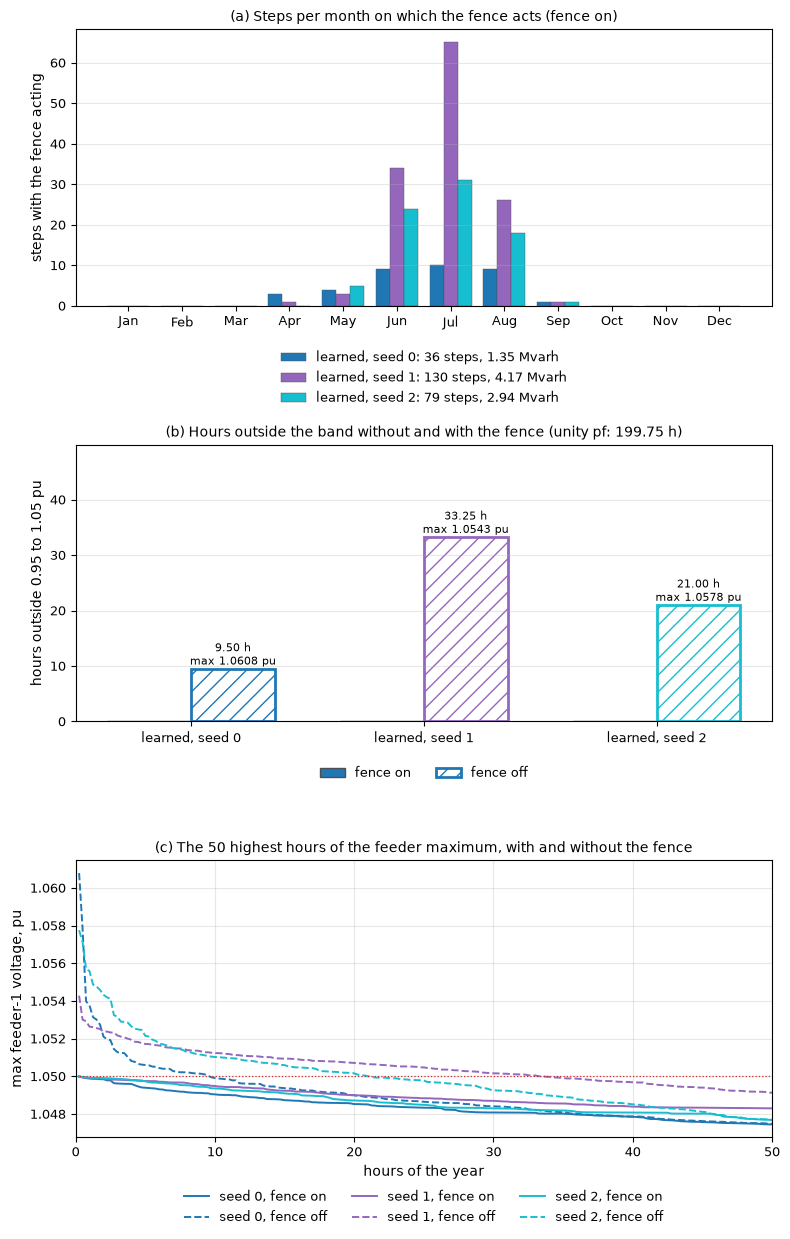

,seed 0,seed 1,seed 2
"hours outside, fence on",0.0000,0.0000,0.0000
"hours outside, fence off",9.5000,33.2500,21.0000
"max V, fence off",1.0608,1.0543,1.0578
"core reward, fence on",-17111.8090,-16827.5619,-16694.5296
"core reward, fence off",-17388.3590,-17265.8955,-17277.5770
"absorbed Mvarh, fence off",370.8728,305.4532,262.7638


In [13]:
POL = {}
for s in SEEDS:
    a = agents.SACAgent(agents.SACConfig(n_threads=2)); a.load(f"../models/sac_seed{s}_best.pt"); POL[s] = a
NOF, KNOF = {}, {}
t0 = time.perf_counter()
for s in SEEDS:
    NOF[s] = from_env(E_off.run_policy(agents.sac_policy(POL[s]), label=f"learned, seed {s}, fence off"))
    KNOF[s] = NOF[s].kpis()
print(f"three full-year runs without the fence in {time.perf_counter() - t0:.0f} s")

fig, axes = plt.subplots(3, 1, figsize=(8, 12.5))
ax = axes[0]
w = 0.26
for i, s in enumerate(SEEDS):
    fm = np.array([Y[f"sac{s}"].fence[month == m].sum() for m in range(1, 13)])
    ax.bar(np.arange(12) + (i - 1) * w, fm, w, color=COL[f"sac{s}"], edgecolor="0.3", lw=0.3,
           label=f"{NAME[f'sac{s}']}: {K[f'sac{s}']['fence_steps']} steps, {K[f'sac{s}']['fence_mvarh']:.2f} Mvarh")
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS); ax.set_ylabel("steps with the fence acting"); ax.grid(axis="y", alpha=0.3)
ax.set_title("(a) Steps per month on which the fence acts (fence on)")
legend_below(ax, ncol=1, dy=-0.12)

ax = axes[1]
xs = np.arange(3)
on = [K[f"sac{s}"]["hours_violation"] for s in SEEDS]; off = [KNOF[s]["hours_violation"] for s in SEEDS]
ax.bar(xs - 0.18, on, 0.36, color=[COL[f"sac{s}"] for s in SEEDS], edgecolor="0.3", label="fence on")
ax.bar(xs + 0.18, off, 0.36, color="white", edgecolor=[COL[f"sac{s}"] for s in SEEDS], lw=2, hatch="//", label="fence off")
for s in SEEDS:
    ax.annotate(f"{off[s]:.2f} h\nmax {KNOF[s]['vmax']:.4f} pu", (s + 0.18, off[s]), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels([NAME[f"sac{s}"] for s in SEEDS]); ax.set_ylabel("hours outside 0.95 to 1.05 pu")
ax.set_ylim(0, max(max(off), 1) * 1.5); ax.grid(axis="y", alpha=0.3)
ax.set_title(f"(b) Hours outside the band without and with the fence (unity pf: {K['unity']['hours_violation']:.2f} h)")
legend_below(ax, ncol=2, dy=-0.12)

ax = axes[2]
for s in SEEDS:
    for r, ls, lab in ((Y[f"sac{s}"], "-", "fence on"), (NOF[s], "--", "fence off")):
        dur = np.sort(r.v.max(axis=1))[::-1][:200]
        ax.plot(np.arange(1, 201) * DT_H, dur, color=COL[f"sac{s}"], ls=ls, lw=1.4, label=f"seed {s}, {lab}")
ax.axhline(1.05, color="tab:red", lw=0.9, ls=":")
ax.set_xlim(0, 50); ax.set_xlabel("hours of the year"); ax.set_ylabel("max feeder-1 voltage, pu"); ax.grid(alpha=0.3)
ax.set_title("(c) The 50 highest hours of the feeder maximum, with and without the fence")
legend_below(ax, ncol=3, dy=-0.15)
plt.tight_layout(); save(fig, "11_fence"); plt.show()
pd.DataFrame({f"seed {s}": {"hours outside, fence on": K[f"sac{s}"]["hours_violation"], "hours outside, fence off": KNOF[s]["hours_violation"],
                            "max V, fence off": KNOF[s]["vmax"], "core reward, fence on": K[f"sac{s}"]["core_reward"],
                            "core reward, fence off": KNOF[s]["core_reward"], "absorbed Mvarh, fence off": KNOF[s]["reactive_absorbed_mvarh"]}
              for s in SEEDS}).round(4)

The fence acts mainly from June to August, the months with the highest midday voltages.
Without it the kept policies leave the band for 9.5, 33.25 and 21.0 hours of the year, with
maxima of 1.054 to 1.061 pu. They remove 83 to 95 % of the violation hours of unity power
factor on their own, but not all of them. Their absorbed energy hardly changes without the
fence, since it adds only 1 to 4 Mvarh. Charging the fence in the training reward made the
policies use it rarely, not avoid needing it. The zero violation hours of the learned
policies are therefore a joint result of policy and fence. The same holds for the milder
fixed curves of section 4.

In this simulation the fence knows the network exactly: it measures the sensitivities with
the model itself and corrects before the step is scored. A fence in the field would need a
network model, or would act one step late on measurements.

## 11. A second, unseen year

The kept checkpoints were chosen as the best of eleven full-year evaluations on 2023, and
the best fixed curve + fence as the best of 15 on the same year: both have seen the year they are
scored on. A fair test needs a year neither has seen. `profiles.py` generates one from the
same models (clear-sky geometry, Markov cloud chain, brochure load shapes, same calendar)
with seed 1 instead of 0: different clouds, different load noise, same climate. It is saved
as `profiles_2023_seed1.h5`. On it, the unity-pf reference, the default and lazy curves (fence off, as they hold the limit
alone), the best fixed curve + fence and the three kept policies (fence on, as trained) are
run once each.

In [14]:
pv1 = pf.pv_profiles(n_units=len(PV_BUSES), names=PV_BUSES, year=YEAR, lat_deg=50.0, step_min=15, seed=1)
ld1 = pf.load_profiles(year=YEAR, step_min=15, seed=1)
pf.save_profiles("profiles_2023_seed1.h5", pv1, ld1, attrs=dict(year=YEAR, seed=1, lat_deg=50.0, step_min=15,
                                                                 pv_buses=PV_BUSES, pv_kw=[int(x) for x in PV_KW]))
pv1, loads1, _ = sim.load_year("profiles_2023_seed1.h5")
print(f"second year: PV capacity factor {pv1.values.mean():.3f} (2023, seed 0: {pv.values.mean():.3f}), "
      f"annual PV maximum {pv1.values.max():.3f} pu (seed 0: {pv.values.max():.3f})")

E1_off = VoltVarEnv(CFG_OFF, pv=pv1, loads=loads1)
E1_on = VoltVarEnv(CFG, pv=pv1, loads=loads1)
H = {}
t0 = time.perf_counter()
H["unity"] = from_env(E1_off.run_policy(None, label="unity pf, second year"))
for k, c in (("default", (1.02, 1.08)), ("lazy", (1.03, 1.10)), ("grid", best_key)):
    H[k] = from_env((E1_on if k == "grid" else E1_off).run_policy(env.constant_policy(env.curve_to_action(c[0], c[1], 0.44)), label=f"{NAME[k]}, second year"))
for s in SEEDS:
    H[f"sac{s}"] = from_env(E1_on.run_policy(agents.sac_policy(POL[s]), label=f"learned, seed {s}, second year"))
KH = {k: r.kpis() for k, r in H.items()}
print(f"{len(H)} full-year runs in {time.perf_counter() - t0:.0f} s")
cols = ["hours_violation", "vmax", "losses_mwh", "reactive_absorbed_mvarh", "fence_steps", "core_reward"]
pd.DataFrame({NAME[k]: {c: KH[k][c] for c in cols} for k in H}).T.round({"hours_violation": 2, "vmax": 4, "losses_mwh": 2,
                                                                       "reactive_absorbed_mvarh": 1, "core_reward": 0})

second year: PV capacity factor 0.155 (2023, seed 0: 0.152), annual PV maximum 0.966 pu (seed 0: 0.966)


unity pf, second year             : 35040 steps in   12.1 s (0.35 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


default curve, second year        : 35040 steps in   21.2 s (0.61 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


lazy curve, second year           : 35040 steps in   19.9 s (0.57 ms per step), safety active on 0 steps, 35040 solves, control-loop failures 0


best fixed curve + fence, second year: 35040 steps in   20.9 s (0.60 ms per step), safety active on 37 steps, 35447 solves, control-loop failures 0


learned, seed 0, second year      : 35040 steps in   27.8 s (0.79 ms per step), safety active on 24 steps, 35304 solves, control-loop failures 0


learned, seed 1, second year      : 35040 steps in   26.2 s (0.75 ms per step), safety active on 157 steps, 36767 solves, control-loop failures 0


learned, seed 2, second year      : 35040 steps in   26.8 s (0.77 ms per step), safety active on 104 steps, 36184 solves, control-loop failures 0
7 full-year runs in 155 s


,hours_violation,vmax,losses_mwh,reactive_absorbed_mvarh,fence_steps,core_reward
unity pf,204.5,1.0618,387.79,0.0,0.0,-33269.0
default curve,0.0,1.0413,400.08,1064.6,0.0,-20426.0
lazy curve,0.0,1.0477,391.70,308.0,0.0,-17064.0
best fixed curve + fence,0.0,1.0500,389.99,211.7,37.0,-16611.0
"learned, seed 0",0.0,1.0500,390.62,380.0,24.0,-17309.0
"learned, seed 1",0.0,1.0500,389.76,316.3,157.0,-17020.0
"learned, seed 2",0.0,1.0500,390.78,273.0,104.0,-16888.0


The two years side by side: (a) the daily maximum feeder voltage at unity power factor,
the size of the problem in each year; (b) the core reward of each controller as a gain
over the default curve of the same year, in per cent; (c) the absorbed reactive energy as a
reduction against the default curve; (d) the losses as a reduction against the default
curve.

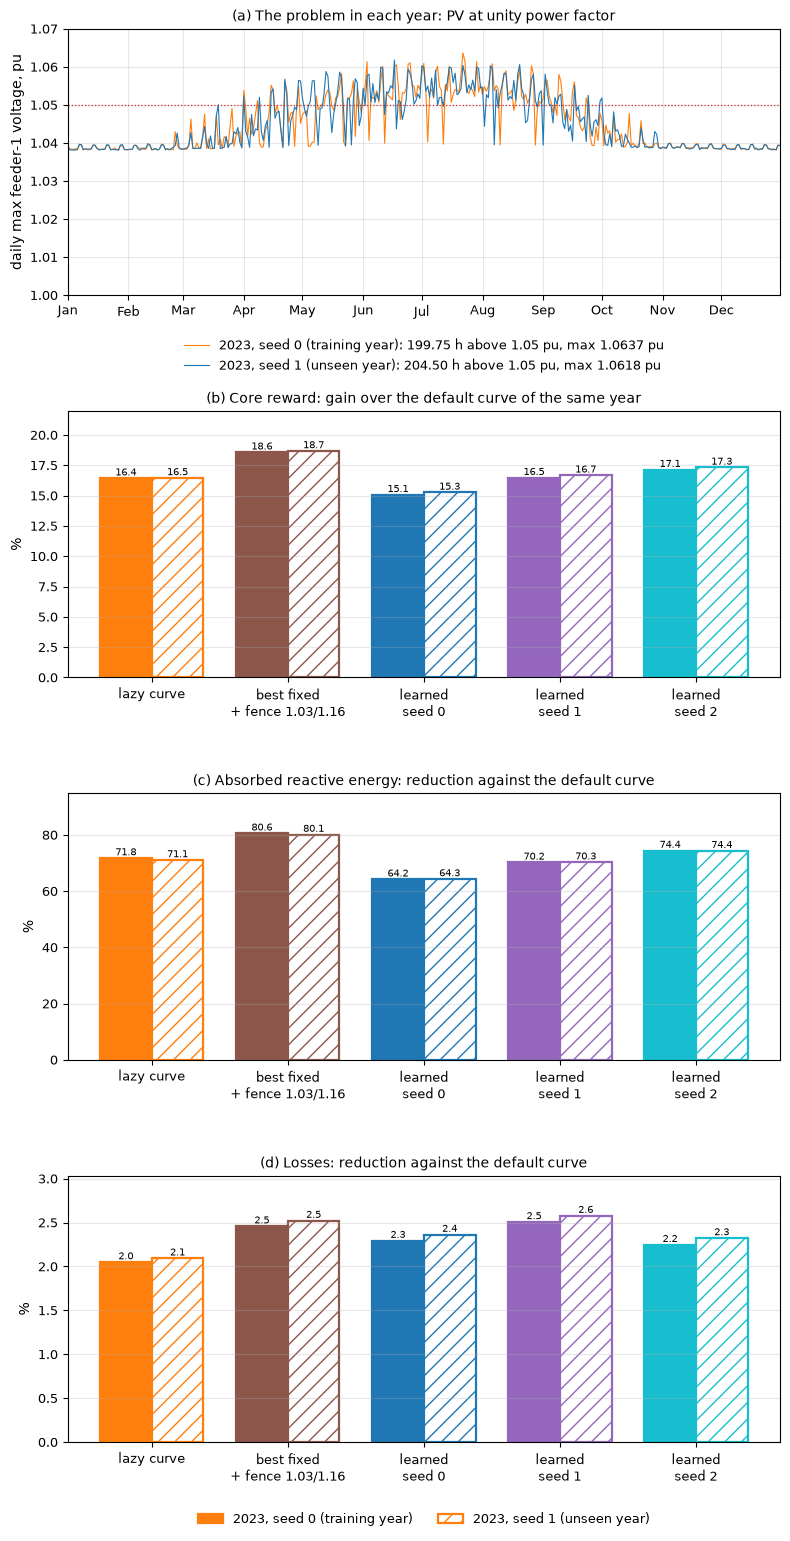

ranking by core reward, training year: best fixed curve + fence > learned, seed 2 > learned, seed 1 > lazy curve > learned, seed 0 > default curve
ranking by core reward, unseen year:   best fixed curve + fence > learned, seed 2 > learned, seed 1 > lazy curve > learned, seed 0 > default curve


In [15]:
keys = ["lazy", "grid", "sac0", "sac1", "sac2"]
def gain(Kd, k, q):
    return 100 * (Kd[k][q] - Kd["default"][q]) / abs(Kd["default"][q])
fig, axes = plt.subplots(4, 1, figsize=(8, 15.5))
ax = axes[0]
for r, c, lab, Kd in ((Y["unity"], "tab:orange", "2023, seed 0 (training year)", K), (H["unity"], "tab:blue", "2023, seed 1 (unseen year)", KH)):
    dmax = r.v.max(axis=1).reshape(365, SPD).max(axis=1)
    ax.plot(np.arange(1, 366), dmax, color=c, lw=0.8, label=f"{lab}: {Kd['unity']['hours_violation']:.2f} h above 1.05 pu, max {Kd['unity']['vmax']:.4f} pu")
ax.axhline(1.05, color="tab:red", lw=0.9, ls=":")
ax.set_xticks(month_start); ax.set_xticklabels(MONTHS); ax.set_xlim(1, 365); ax.set_ylim(1.00, 1.07)
ax.set_ylabel("daily max feeder-1 voltage, pu"); ax.grid(alpha=0.3); ax.set_title("(a) The problem in each year: PV at unity power factor")
legend_below(ax, ncol=1, dy=-0.12)
for ax, (q, sign, title) in zip(axes[1:], (("core_reward", 1, "(b) Core reward: gain over the default curve of the same year"),
                                           ("reactive_absorbed_mvarh", -1, "(c) Absorbed reactive energy: reduction against the default curve"),
                                           ("losses_mwh", -1, "(d) Losses: reduction against the default curve"))):
    for i, (Kd, hatch, lab) in enumerate(((K, "", "2023, seed 0 (training year)"), (KH, "//", "2023, seed 1 (unseen year)"))):
        y = [sign * gain(Kd, k, q) for k in keys]
        xs = np.arange(len(keys)) + (i - 0.5) * 0.38
        ax.bar(xs, y, 0.38, color=[COL[k] for k in keys] if i == 0 else "white", edgecolor=[COL[k] for k in keys], lw=1.6, hatch=hatch, label=lab)
        for xx, yy in zip(xs, y):
            ax.annotate(f"{yy:.1f}", (xx, yy), xytext=(0, 2), textcoords="offset points", ha="center", fontsize=7.5)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([NAME[k].replace("learned, ", "learned\n").replace("best fixed curve + fence", f"best fixed\n+ fence {best_key[0]}/{best_key[1]}") for k in keys])
    ax.set_ylabel("%"); ax.grid(axis="y", alpha=0.3); ax.set_title(title)
    lo, hi = ax.get_ylim(); ax.set_ylim(min(lo, 0), hi * 1.12)
legend_below(axes[3], ncol=2, dy=-0.22)
plt.tight_layout(); save(fig, "12_unseen_year"); plt.show()
rank0 = sorted(keys + ["default"], key=lambda k: -K[k]["core_reward"]); rank1 = sorted(keys + ["default"], key=lambda k: -KH[k]["core_reward"])
print("ranking by core reward, training year:", " > ".join(NAME[k] for k in rank0))
print("ranking by core reward, unseen year:  ", " > ".join(NAME[k] for k in rank1))

The unseen year is slightly sunnier (capacity factor 0.155 against 0.152) and at unity power
factor has 204.5 hours above 1.05 pu, against 199.75. The results barely move. The gain of
each controller over the default curve of the same year changes by at most 0.2 percentage
points in core reward and 0.7 points in reactive energy. The ranking is identical in both
years: best fixed curve + fence, learned seed 2, learned seed 1, lazy curve, learned seed 0,
default curve. Selecting the checkpoints and the grid curve on the 2023 year did not flatter
them measurably. The conclusions do not rest on one weather realisation from the profile
generator, though both years come from the same generator (section 13).

## 12. Two details of the learned policies

**The irradiance input.** Each agent observes its own P of the previous step (notebook 05)
and the irradiance of the current step. Irradiance is P before the inverter, so the two
carry almost the same information; what the irradiance adds is the change over the last
15 minutes. Panel (a) plots the current irradiance against the previous-step P (both in pu
of Pmpp) for all daylight unit-steps of seed 0's year; panel (b) the distribution of their
difference, which is all the irradiance input can add.

**Steep curves.** V4 may come as close as 0.02 pu to V3. A curve that steep turns a small
voltage change into a large change of Q, and on some steps the inverter's reactive power
went beyond the Q4 the curve itself set. Panel (c) shows the distribution of V4 minus V3
over daylight unit-steps for each seed, with the number of unit-steps on which the absorbed
Q exceeded Q4 by more than 0.01 pu of kVA; steps on which the fence acted are excluded,
since the fence may add absorption beyond the curve by design.

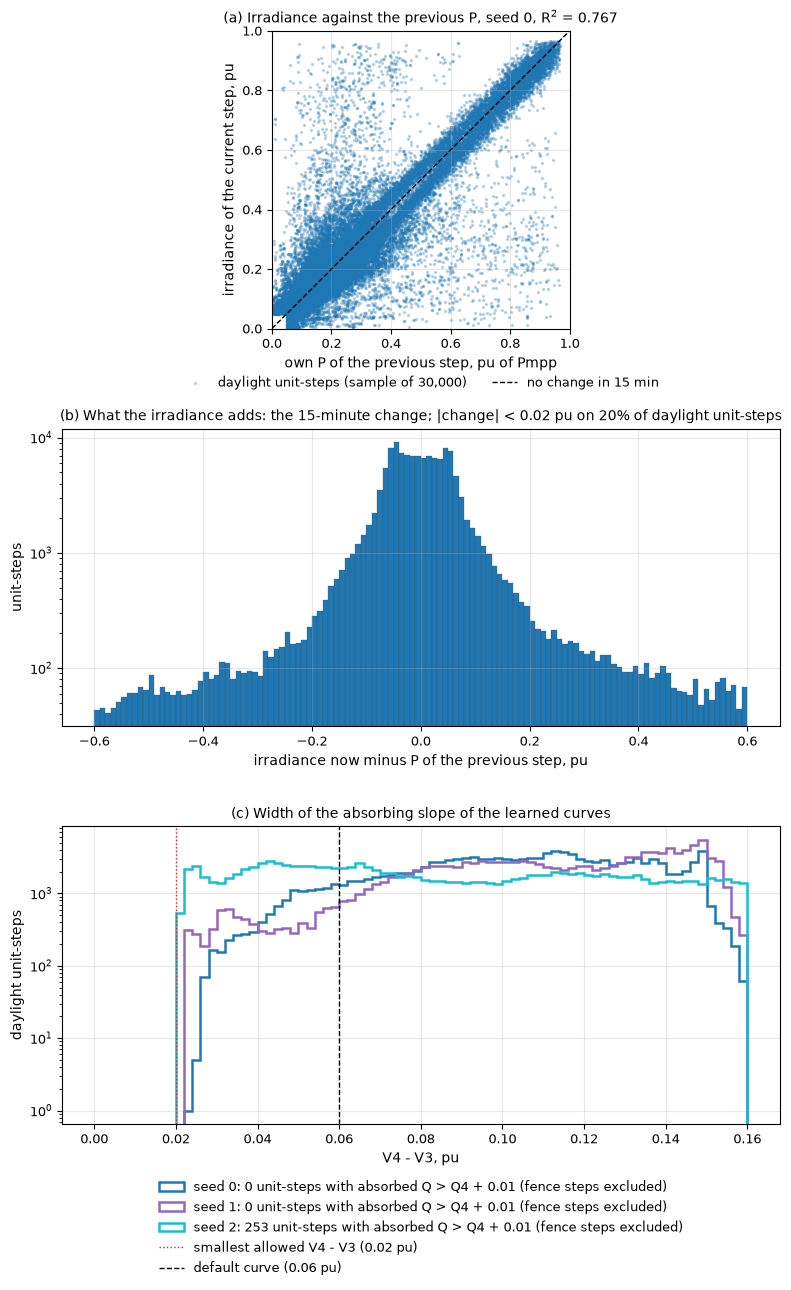

irradiance vs previous P: R^2 0.7671; median |change| 0.0477 pu
seed 0: median V4 - V3 0.106 pu, share below 0.03 pu 0.2%, unit-steps with absorbed Q above Q4 + 0.01 outside fence steps: 0 of 315360
seed 1: median V4 - V3 0.115 pu, share below 0.03 pu 0.8%, unit-steps with absorbed Q above Q4 + 0.01 outside fence steps: 0 of 315360
seed 2: median V4 - V3 0.084 pu, share below 0.03 pu 6.3%, unit-steps with absorbed Q above Q4 + 0.01 outside fence steps: 253 of 315360


In [16]:
r = Y["sac0"]
irr_now = r.irr[1:]; p_prev = r.p[:-1] / PV_KW
dayl = (irr_now > 0.05) | (p_prev > 0.05)
diff = (irr_now - p_prev)[dayl]
r2 = np.corrcoef(irr_now[dayl], p_prev[dayl])[0, 1] ** 2
fig, axes = plt.subplots(3, 1, figsize=(8, 13))
ax = axes[0]
pick = rng.choice(dayl.sum(), size=min(30000, dayl.sum()), replace=False)
ax.scatter(p_prev[dayl][pick], irr_now[dayl][pick], s=2, alpha=0.25, color="tab:blue", label="daylight unit-steps (sample of 30,000)")
ax.plot([0, 1], [0, 1], color="black", lw=1, ls="--", label="no change in 15 min")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlabel("own P of the previous step, pu of Pmpp"); ax.set_ylabel("irradiance of the current step, pu")
ax.set_title(f"(a) Irradiance against the previous P, seed 0, R$^2$ = {r2:.3f}")
legend_below(ax, ncol=2, dy=-0.12)
ax = axes[1]
ax.hist(diff, bins=np.linspace(-0.6, 0.6, 121), color="tab:blue", edgecolor="0.3", lw=0.2)
ax.set_yscale("log"); ax.set_xlabel("irradiance now minus P of the previous step, pu"); ax.set_ylabel("unit-steps"); ax.grid(alpha=0.3)
ax.set_title(f"(b) What the irradiance adds: the 15-minute change; |change| < 0.02 pu on {np.mean(np.abs(diff) < 0.02):.0%} of daylight unit-steps")
ax = axes[2]
steep = {}
for s in SEEDS:
    rr = Y[f"sac{s}"]; dl = rr.irr > 0.05
    gapv = (rr.curves[:, :, 1] - rr.curves[:, :, 0])[dl]
    over = ((-rr.q / PV_KVA) > rr.curves[:, :, 2] + 0.01) & (rr.q < 0) & ~rr.fence[:, None]   # the fence may exceed Q4 by design
    steep[s] = dict(overrun_unit_steps=int(over.sum()), share_gap_below_003=float(np.mean(gapv < 0.03)), gap_median=float(np.median(gapv)))
    ax.hist(gapv, bins=np.linspace(0.0, 0.16, 81), histtype="step", lw=1.8, color=COL[f"sac{s}"],
            label=f"seed {s}: {steep[s]['overrun_unit_steps']} unit-steps with absorbed Q > Q4 + 0.01 (fence steps excluded)")
ax.axvline(0.02, color="tab:red", lw=1, ls=":", label="smallest allowed V4 - V3 (0.02 pu)")
ax.axvline(0.06, color=COL["default"], lw=1, ls="--", label="default curve (0.06 pu)")
ax.set_yscale("log"); ax.set_xlabel("V4 - V3, pu"); ax.set_ylabel("daylight unit-steps"); ax.grid(alpha=0.3)
ax.set_title("(c) Width of the absorbing slope of the learned curves")
legend_below(ax, ncol=1, dy=-0.15)
plt.tight_layout(); save(fig, "13_details"); plt.show()
print(f"irradiance vs previous P: R^2 {r2:.4f}; median |change| {np.median(np.abs(diff)):.4f} pu")
for s in SEEDS:
    print(f"seed {s}: median V4 - V3 {steep[s]['gap_median']:.3f} pu, share below 0.03 pu {steep[s]['share_gap_below_003']:.1%}, "
          f"unit-steps with absorbed Q above Q4 + 0.01 outside fence steps: {steep[s]['overrun_unit_steps']} of {35040 * 9}")

**Irradiance.** The current irradiance and the previous-step P share only R$^2$ = 0.77. The
median 15-minute change is 0.048 pu, and at cloud edges it reaches several tenths of a pu.
The irradiance input is therefore not redundant: it gives each agent a genuine one-step
look-ahead that its P observation does not have. Whether the policies use it is a separate
question, which only a training run without that input could answer.

**Steep curves.** Seed 2 spends 6.3 % of its daylight unit-steps with V4 - V3 below 0.03 pu,
the other seeds under 1 %. Outside the fence steps, seed 2's inverters absorbed more than the
Q4 of their own curve on 253 unit-steps, against none for seeds 0 and 1. On a curve that
steep, a small voltage change moves Q a long way, and the volt-var control loop of the
simulation appears to settle beyond the curve. A wider minimum V4 - V3 (for
example 0.04 pu) would remove this, at no visible cost to the other seeds.

## 13. Limitations

- **Synthetic profiles.** PV and load come from simple closed-form models with a seeded
  random cloud chain (notebook 03), not from measurements. The second year of section 11 is a
  new draw from the same generator: it tests robustness to weather, not to a different
  climate or load mix.
- **One feeder, one PV size.** The CIGRE European MV feeder 1 with nine units of 680 to 740
  kW and inverters of 1.1 Pmpp. At this size the default curve never fails, so the study
  compares ways of holding the limit more cheaply, not ways of holding a limit that simple
  curves cannot hold.
- **Balanced, quasi-static simulation.** Positive-sequence power flow every 15 minutes; no
  unbalance, no dynamics inside the 15 minutes, no measurement noise, no communication delay.
  The TR1 tap is fixed at +4.375 %; no on-load tap changer acts.
- **Inverters at night.** The OpenDSS inverter model keeps its reactive capability at zero
  active power, so curves act at night. Many real inverters disconnect below a minimum power,
  which would remove most of the default curve's absorption (479 of 1,040 Mvarh) and part of
  the learned policies'.
- **A perfect fence.** The safety layer computes its corrections with the exact network model
  before the step is scored. The learned policies and the milder fixed curves rely on it.
- **The reward.** The weights are one choice. The voltage term is weak enough that curves
  breaking the limit can outscore curves holding it (section 4). With another weighting the
  rankings among the milder controllers may change.
- **Training budget.** Three seeds, 500 single-day episodes per seed, one algorithm (soft
  actor-critic with a shared actor), one set of hyperparameters. The spread between seeds is
  as large as the differences between the controllers being compared.
- **The bound covers 32 days**, not the whole year; the full-year comparison has no OPF.

## 14. Conclusions

The question of the study was whether PV inverters that see only their own bus can learn to
set their IEEE 1547 volt-var curve so that the feeder stays inside 0.95 to 1.05 pu with less
reactive effort and lower losses than the standard's default curve.

1. **Against the default curve: yes.** With the fence, the learned policies keep zero
   violation hours over the full year and cut the absorbed reactive energy by 64 to 74 %, the
   losses by 2.2 to 2.5 % and the core reward penalty by 15 to 17 %. They do so on a second,
   unseen year as well.
2. **Against a well-chosen fixed curve: no.** The hand-set lazy curve (V3 1.03, V4 1.10) is
   the best fixed curve that holds the limit alone, and the learned policies are level with
   it. With the same fence as the learned policies, the mildest fixed curve of a 15-point
   grid (V3 1.03, V4 1.16) beats all three learned policies in both years. Learning a
   time-varying local curve bought nothing that a fixed curve at the edge of the standard's
   ranges did not already give.
3. **Why not.** The remaining gap to the feeder-wide optimum is reactive energy spent in the
   wrong place and at the wrong time. The OPF absorbs only when a bus would pass the limit,
   and mostly at the far ends of the laterals (84.5 % at buses 7, 10 and 11). The local
   controllers absorb whenever their own voltage is high, spread over all units, and, in the
   learned case, also through the night. Knowing *whether* the feeder is near its limit and
   *which* units move the critical bus is information about the whole feeder. No unit can
   read it from its own terminal voltage, however long it trains.
4. **The limit needs its own guard.** Neither the learned policies (9.5 to 33 h outside the
   band without the fence) nor the milder fixed curves hold 1.05 pu alone. Under the reward
   used here, a small breach costs less than the reactive power saved. A safety layer that
   enforces the limit is part of the controller, not an add-on.

What follows from this is a change of level, not more training of the same local agents.
The information missing locally (how close the feeder is to its limit, where the critical bus
is, when absorption is wasted) is available at the substation. A slow feeder-level
coordinator could pass it to the units as a small signal: a per-unit budget, a shift of V3,
or simply "absorb now" and "stand down". It could also move the transformer tap, which acts
on all buses at once. Whether such a coordinator can close the gap to the OPF while the fast
decisions stay local, and how it behaves with delayed or lost messages, is the natural next
question.

## 15. Save the results

`results_summary.json` collects the numbers of this notebook: the full-year and
sampled-day KPIs of every controller, the grid, the runs without the fence, the unseen
year and the two details of section 12. The figures are in `figures/07_*.png`.

In [17]:
def slim(k):
    return {c: k[c] for c in ("hours_violation", "vmax", "vmin", "losses_mwh", "reactive_absorbed_mvarh", "reactive_injected_mvarh",
                              "curtailed_mwh", "fence_steps", "fence_mvarh", "core_reward")}
out = dict(
    setup=dict(year=YEAR, tr1_tap_pct=CFG.tr1_tap_pct, kva_ratio=CFG.kva_ratio, pv_buses=PV_BUSES, pv_kw=[float(x) for x in PV_KW],
               reward_weights=dict(viol=CFG.w_viol, loss=CFG.w_loss, q=CFG.w_q, curt=CFG.w_curt), sample_days=SAMPLE_DAYS,
               worst_day=sel["worst_day"], typical_day=sel["typical_day"]),
    full_year={Y[k].label: slim(K[k]) for k in list(Y)},
    sampled_days={S[k].label: slim(KS[k]) for k in S},
    gap_closed_sampled_days={NAME[k]: v for k, v in gap.items()},
    learned_curves=band_stats,
    absorbed_day_night_mvarh={NAME[k]: v for k, v in night_split.items()},
    fixed_curve_grid=[dict(V3=v3, V4=v4, **slim(k)) for (v3, v4), k in grid.items()],
    best_fixed_curve_with_fence=dict(V3=best_key[0], V4=best_key[1]),
    best_fixed_curve_without_fence=dict(V3=best_off[0], V4=best_off[1]),
    fixed_curve_grid_fence_on=[dict(V3=v3, V4=v4, **slim(k)) for (v3, v4), k in grid_on.items()],
    fence_off={f"seed {s}": slim(KNOF[s]) for s in SEEDS},
    unseen_year=dict(profiles="profiles_2023_seed1.h5", seed=1, runs={H[k].label: slim(KH[k]) for k in H}),
    irradiance_vs_previous_p_r2=float(r2),
    steep_curves={f"seed {s}": v for s, v in steep.items()},
    runtime_s=time.perf_counter() - T_NB0)
with open("results_summary.json", "w") as f:
    json.dump(out, f, indent=2)
print("results_summary.json written;", len(out["full_year"]), "full-year runs,", len(out["fixed_curve_grid"]), "grid curves")
print("figures:", sorted(f for f in os.listdir("../figures") if f.startswith("07_")))
print(f"notebook runtime {(time.perf_counter() - T_NB0) / 60:.1f} min")

results_summary.json written; 11 full-year runs, 15 grid curves
figures: ['07_01_curves.png', '07_02_full_year.png', '07_03_fixed_curve_grid.png', '07_04_duration.png', '07_05_q_maps.png', '07_06_months.png', '07_07_units.png', '07_08_worst_day.png', '07_09_typical_day.png', '07_10_sampled_days.png', '07_11_fence.png', '07_12_unseen_year.png', '07_13_details.png']
notebook runtime 14.4 min
